In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install opencv-python

In [ ]:
# computer vision
import cv2
from google.colab.patches import cv2_imshow
from imutils.object_detection import non_max_suppression
from skimage.metrics import structural_similarity as ssim
from scipy.io import loadmat

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from shapely.geometry import box
from collections import defaultdict
from pandas.plotting import table
import seaborn as sns

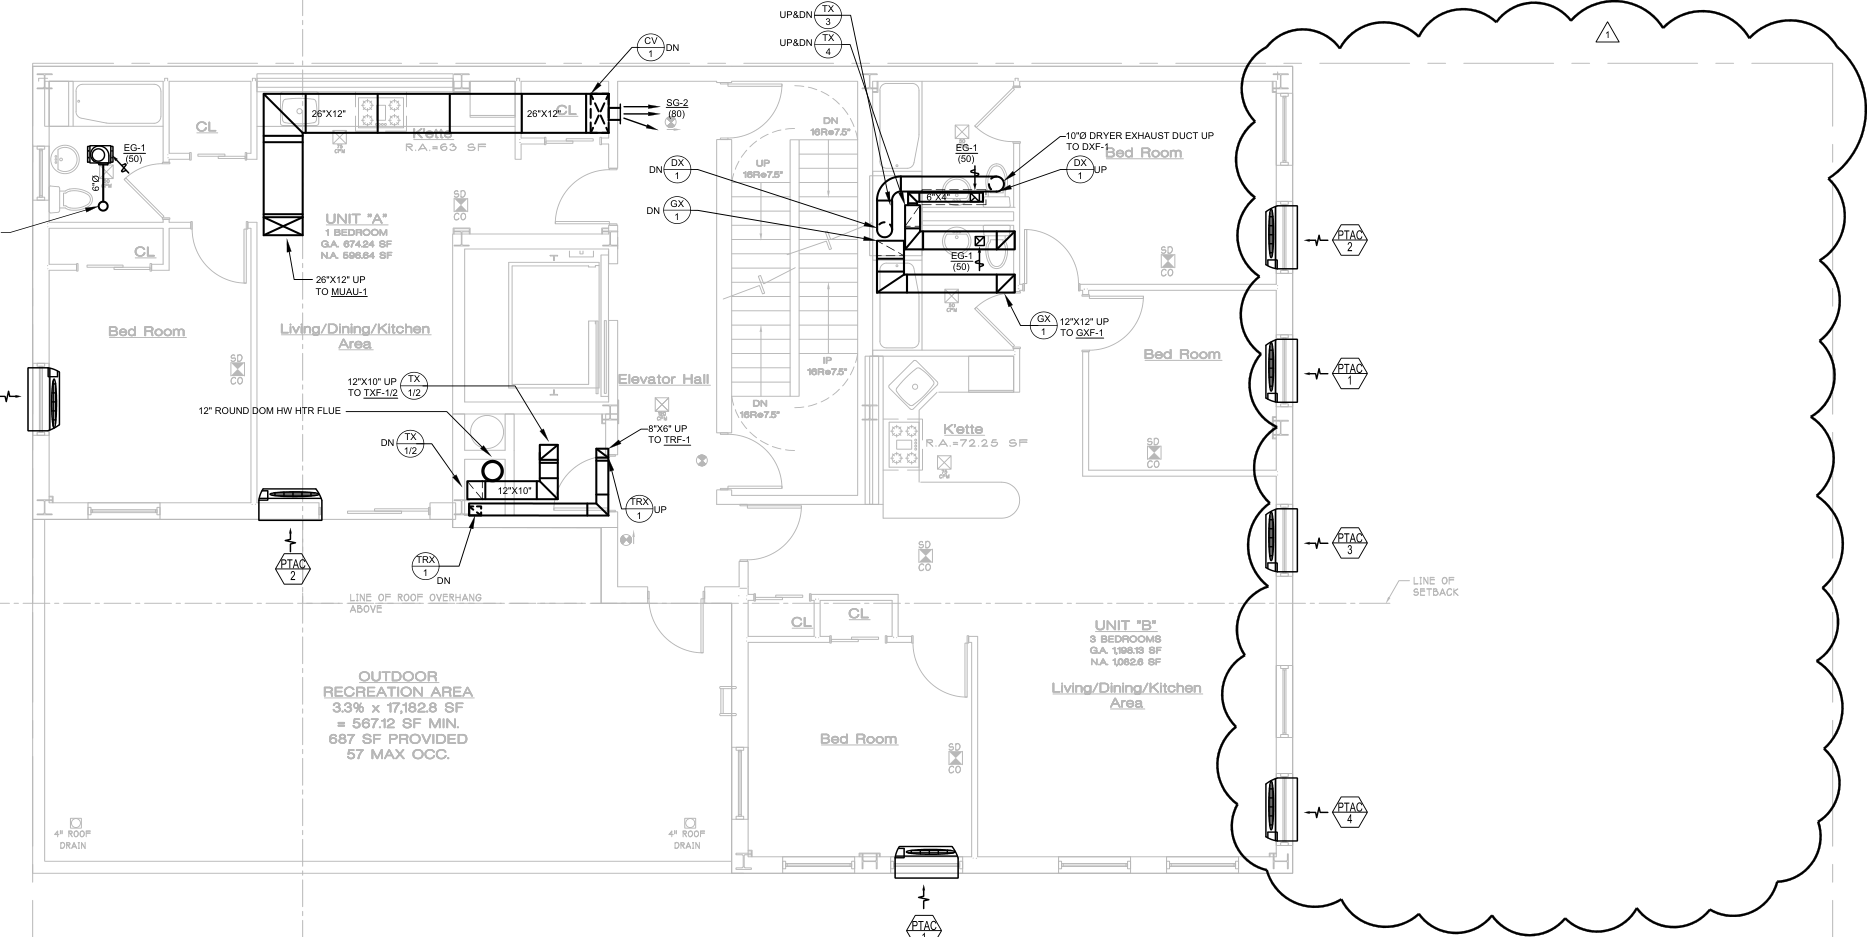

In [ ]:
# Load the image using OpenCV
img_48 = cv2.imread("/content/drive/MyDrive/*Datasets/processed_data/page_48.png")
mat_file_path_48 = '/content/drive/MyDrive/*Datasets/ground truth data/page_48_labels.mat'
img_49 = cv2.imread("/content/drive/MyDrive/*Datasets/processed_data/page_49.png")
mat_file_path_49 = '/content/drive/MyDrive/*Datasets/ground truth data/page_49_labels.mat'

cv2_imshow(img_48)
cv2_imshow(img_49)

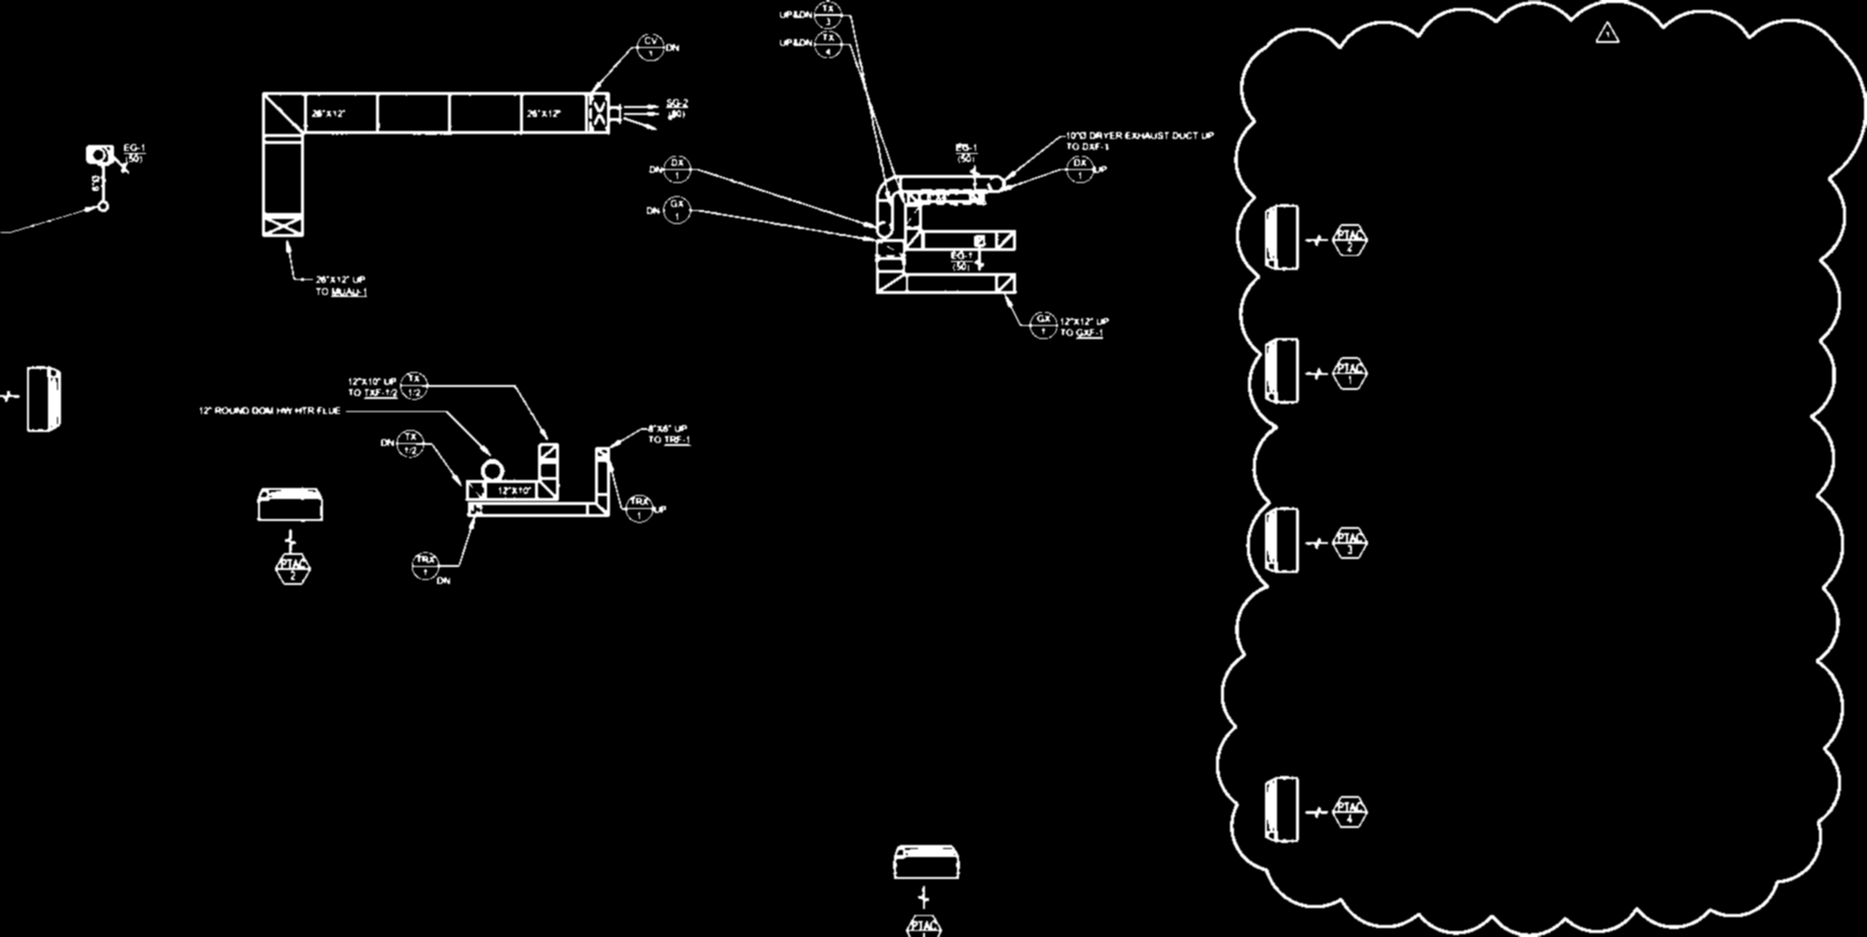

In [ ]:
# Preprocess the input image
def preprocess_image(img):
    if len(img.shape) == 3:  # Convert to grayscale if it's a color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    eroded = cv2.erode(closed, kernel, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=1)
    dilated_new = cv2.GaussianBlur(dilated, (3, 3), 0)
    return dilated_new

dilated = preprocess_image(img)
cv2_imshow(dilated)

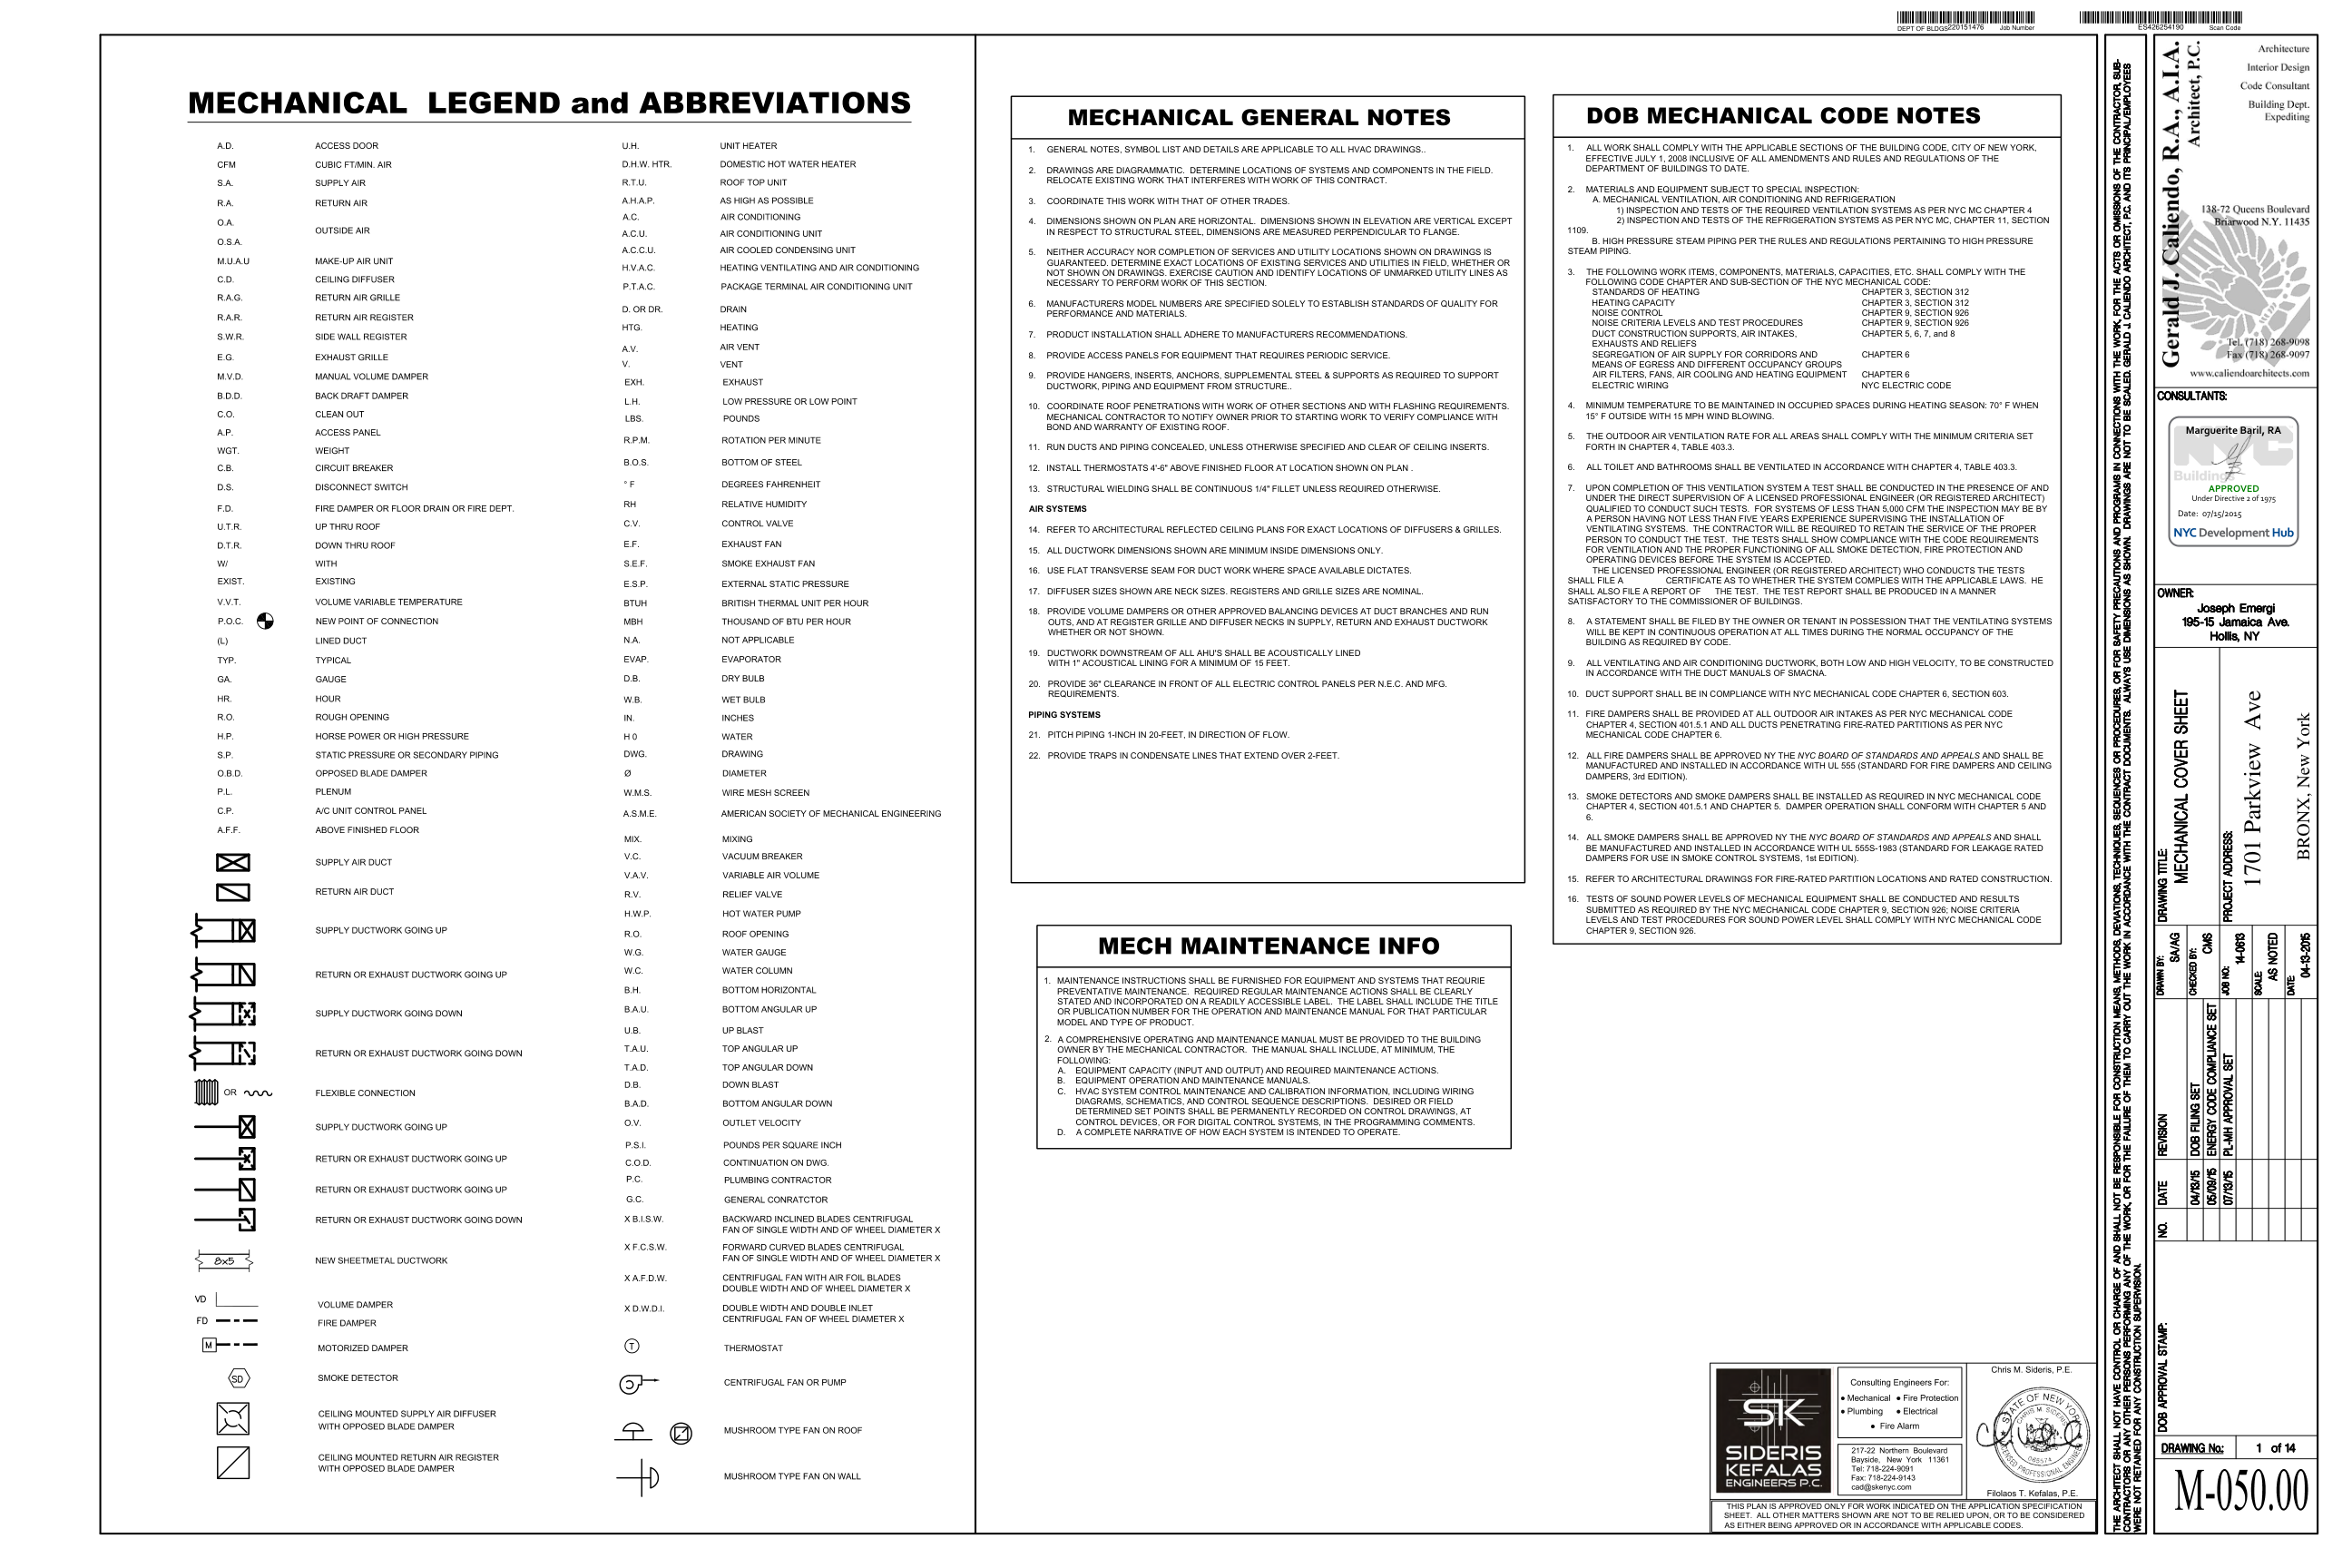

In [ ]:
# Load the image using OpenCV
tmp_img = cv2.imread("/content/drive/MyDrive/*Datasets/Parkview Data Images/page_47.png")

cv2_imshow(tmp_img)

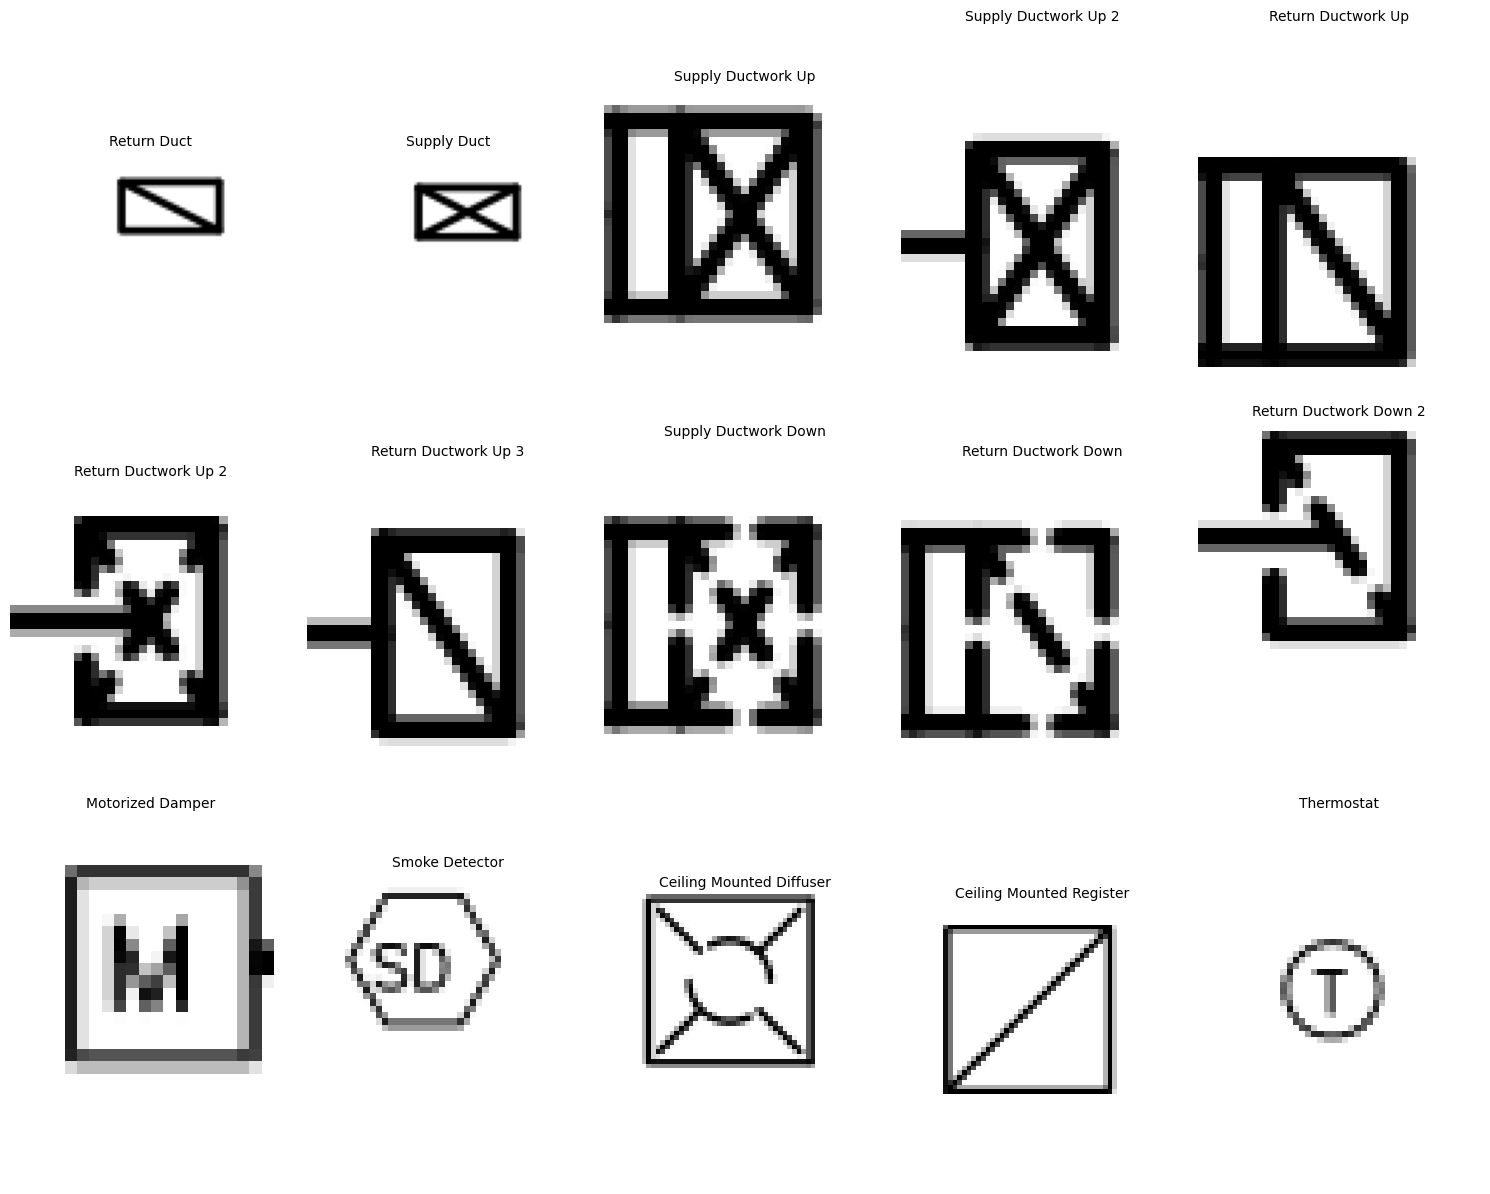

In [ ]:
# Define crop coordinates for the supply and return ducts (adjust these as needed)
# Format: img[y1:y2, x1:x2]
# Example coordinates - these need to be adjusted based on the actual location in the image
supply_duct_crop = tmp_img[930:970, 200:300]
return_duct_crop = tmp_img[965:1005, 200:300]

supply_ductwork_up_crop = tmp_img[1010:1040, 255:290]
supply_ductwork_up_crop_2 = tmp_img[1215:1260, 255:290]

return_ductwork_up_crop = tmp_img[1045:1090, 255:290]
return_ductwork_up_crop_2 = tmp_img[1260:1290, 255:290]
return_ductwork_up_crop_3 = tmp_img[1290:1325, 255:290]

supply_ductwork_down_crop = tmp_img[1095:1135, 255:290]

return_ductwork_down_crop = tmp_img[1140:1175, 255:290]
return_ductwork_down_crop_2 = tmp_img[1330:1375, 255:290]

motorized_damper_crop = tmp_img[1470:1500, 220:240]

smoke_detector_crop = tmp_img[1505:1545, 245:290]
ceiling_mounted_diffuser_crop = tmp_img[1545:1590, 230:290]
ceiling_mounted_register_crop = tmp_img[1590:1630, 230:290]

thermostat_crop = tmp_img[1455:1515, 685:710]

# Create a list of cropped images and their labels
cropped_images = [
    (return_duct_crop, "Return Duct"),
    (supply_duct_crop, "Supply Duct"),
    (supply_ductwork_up_crop, "Supply Ductwork Up"),
    (supply_ductwork_up_crop_2, "Supply Ductwork Up 2"),
    (return_ductwork_up_crop, "Return Ductwork Up"),
    (return_ductwork_up_crop_2, "Return Ductwork Up 2"),
    (return_ductwork_up_crop_3, "Return Ductwork Up 3"),
    (supply_ductwork_down_crop, "Supply Ductwork Down"),
    (return_ductwork_down_crop, "Return Ductwork Down"),
    (return_ductwork_down_crop_2, "Return Ductwork Down 2"),
    (motorized_damper_crop, "Motorized Damper"),
    (smoke_detector_crop, "Smoke Detector"),
    (ceiling_mounted_diffuser_crop, "Ceiling Mounted Diffuser"),
    (ceiling_mounted_register_crop, "Ceiling Mounted Register"),
    (thermostat_crop, "Thermostat"),
]

# Number of columns in the grid
num_cols = 5
num_rows = -(-len(cropped_images) // num_cols)  # Calculate rows dynamically based on the number of images

# Create the figure and axes
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 4))
axes = axes.flatten()  # Flatten the axes for easier indexing

# Loop through the cropped images and display them
for idx, (crop, label) in enumerate(cropped_images):
    axes[idx].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for proper display
    axes[idx].axis('off')  # Remove axis
    axes[idx].set_title(label, fontsize=10)

# Turn off unused axes
for idx in range(len(cropped_images), len(axes)):
    axes[idx].axis('off')

# Adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
# Preprocess Templates
def preprocess_template(template_img):

    gray = cv2.GaussianBlur(template_img, (3, 3), 0)

    # Step 2: Threshold to binary (invert foreground/background)
    _, binary_img = cv2.threshold(template_img, 180, 255, cv2.THRESH_BINARY_INV)

    # Step 3: Apply morphological operations
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=2)
    eroded = cv2.erode(closed, kernel, iterations=3)
    refined = cv2.dilate(eroded, kernel, iterations=3)

    # Step 4: Crop to content
    coords = cv2.findNonZero(refined)  # Find non-zero pixels
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)  # Get bounding box around content
        cropped = refined[y:y+h, x:x+w]  # Crop the image
    else:
        cropped = refined  # If no non-zero pixels, return the refined image

    return cropped


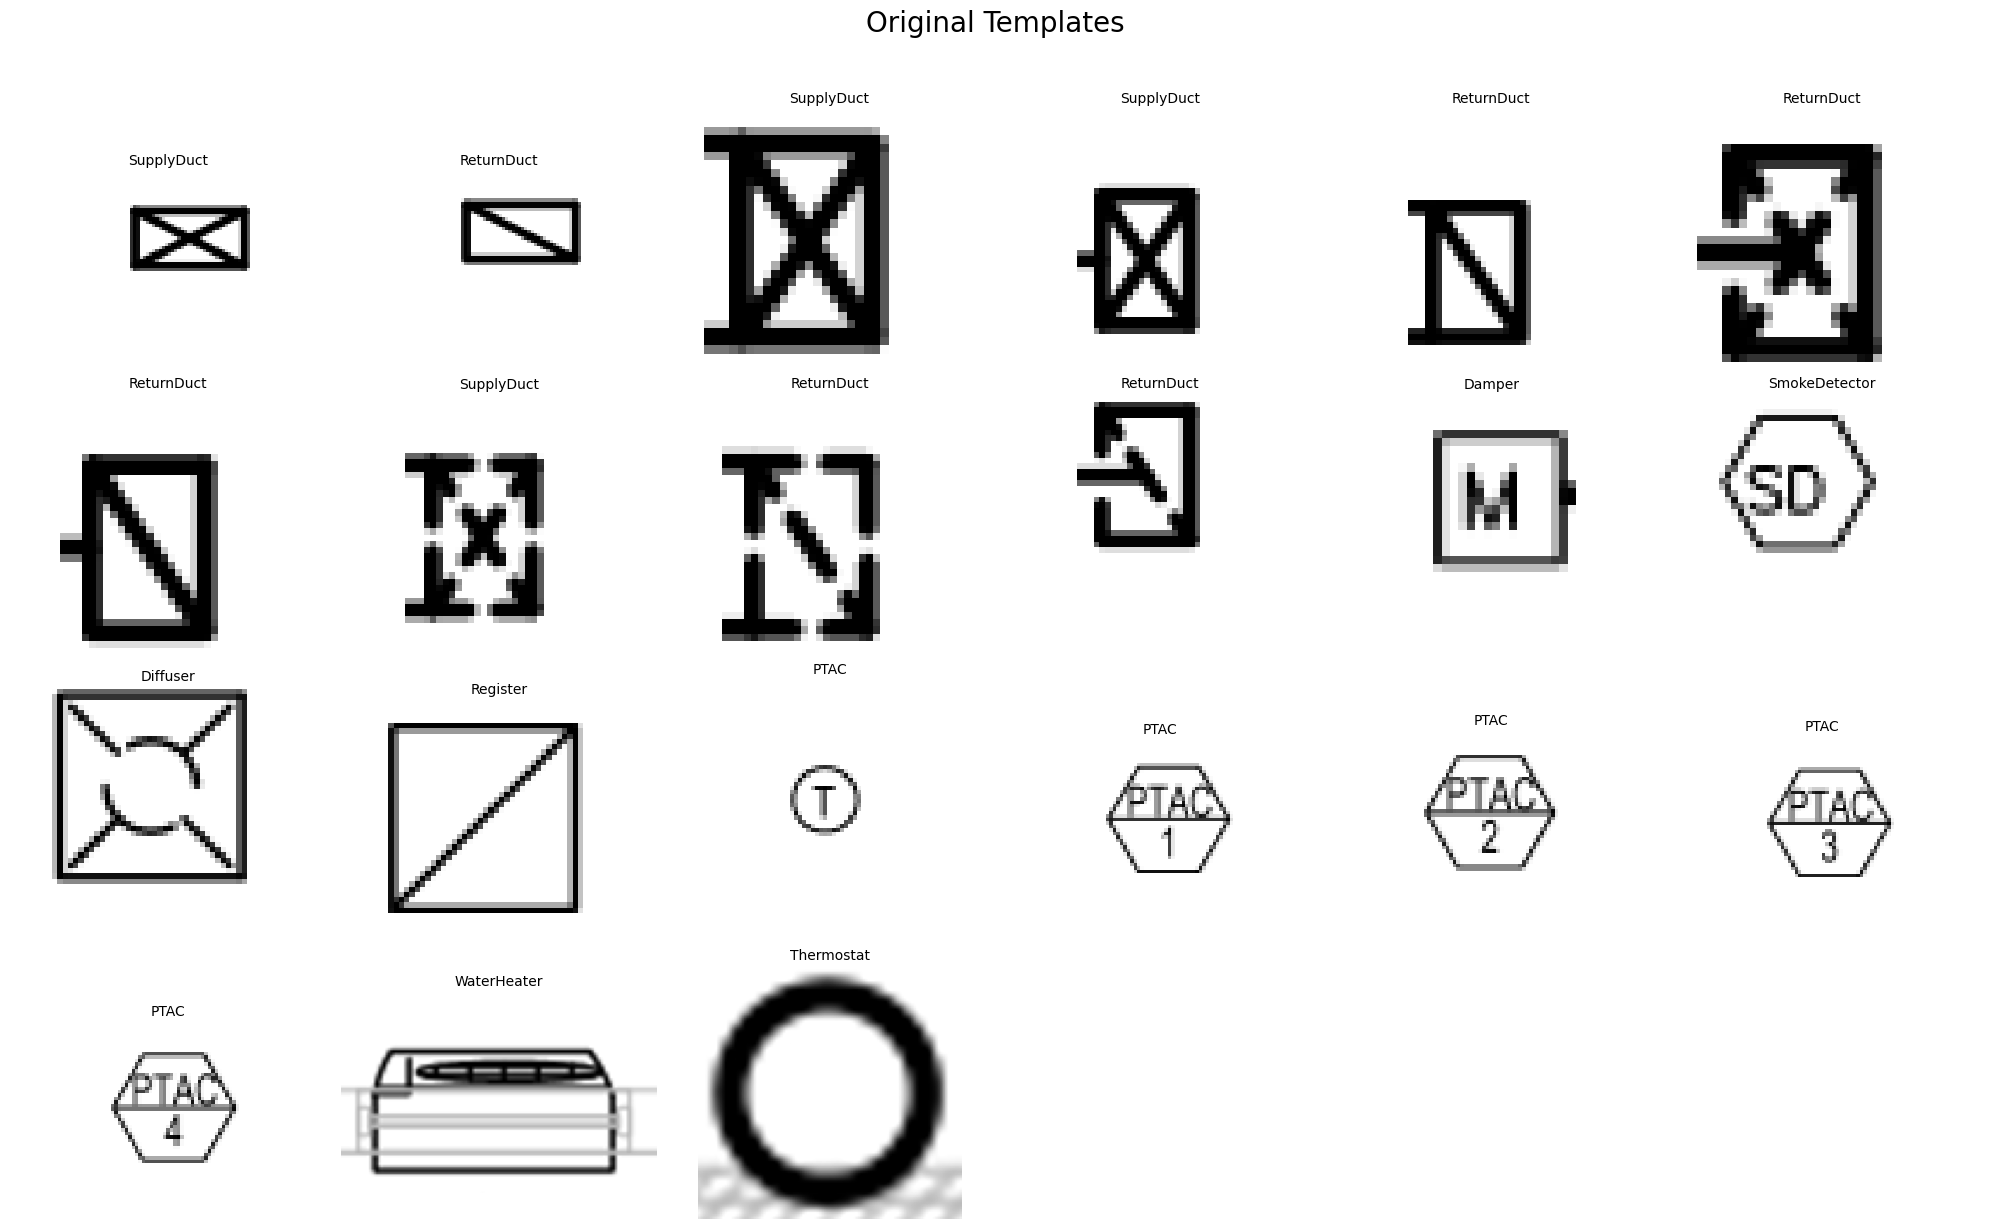

Total number of templates: 21


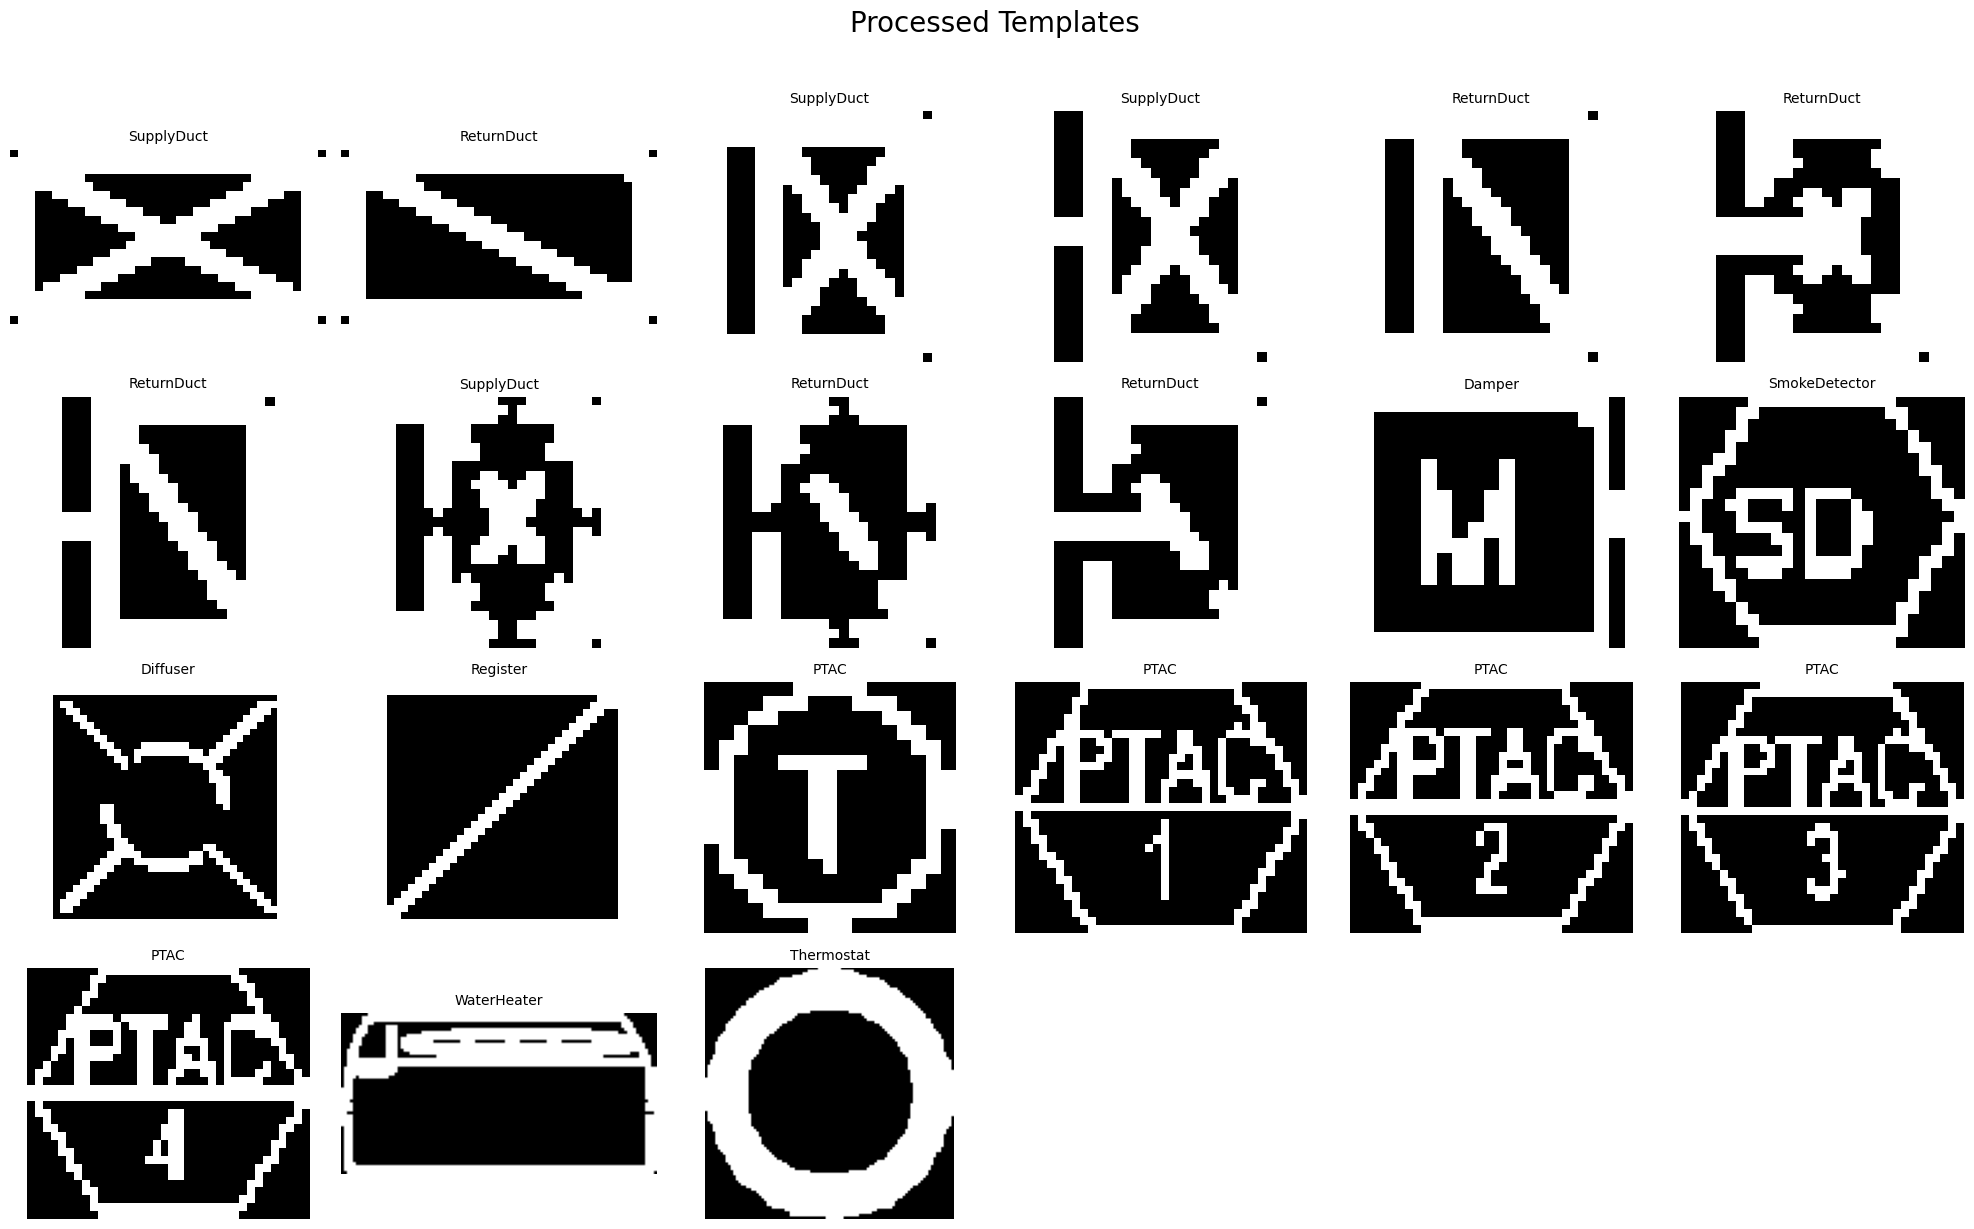

In [ ]:
# Define crop coordinates for additional templates with variations
supply_duct_crop = tmp_img[930:970, 200:300]
return_duct_crop = tmp_img[965:1005, 200:300]
supply_ductwork_up_crop = tmp_img[1010:1040, 260:290]
supply_ductwork_up_crop_2 = tmp_img[1215:1260, 260:290]
return_ductwork_up_crop = tmp_img[1045:1090, 260:290]
return_ductwork_up_crop_2 = tmp_img[1260:1290, 260:290]
return_ductwork_up_crop_3 = tmp_img[1290:1325, 260:290]
supply_ductwork_down_crop = tmp_img[1095:1135, 260:290]
return_ductwork_down_crop = tmp_img[1140:1175, 260:290]
return_ductwork_down_crop_2 = tmp_img[1330:1375, 260:290]
motorized_damper_crop = tmp_img[1470:1500, 220:240]
smoke_detector_crop = tmp_img[1505:1545, 245:290]
ceiling_mounted_diffuser_crop = tmp_img[1545:1590, 230:290]
ceiling_mounted_register_crop = tmp_img[1590:1630, 230:290]
thermostat_crop = tmp_img[1455:1515, 685:710]

# Convert cropped templates to grayscale
cropped_templates = [
    cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    for crop in [
        supply_duct_crop,
        return_duct_crop,
        supply_ductwork_up_crop,
        supply_ductwork_up_crop_2,
        return_ductwork_up_crop,
        return_ductwork_up_crop_2,
        return_ductwork_up_crop_3,
        supply_ductwork_down_crop,
        return_ductwork_down_crop,
        return_ductwork_down_crop_2,
        motorized_damper_crop,
        smoke_detector_crop,
        ceiling_mounted_diffuser_crop,
        ceiling_mounted_register_crop,
        thermostat_crop
    ]
]

# Define additional template paths
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Hot Water Heater.png'
]

# Define names for all templates, including variations
template_names = [
    'SupplyDuct',
    'ReturnDuct',
    'SupplyDuct',
    'SupplyDuct',
    'ReturnDuct',
    'ReturnDuct',
    'ReturnDuct',
    'SupplyDuct',
    'ReturnDuct',
    'ReturnDuct',
    'Damper',
    'SmokeDetector',
    'Diffuser',
    'Register',
    'PTAC',
    'PTAC',
    'PTAC',
    'PTAC',
    'PTAC',
    'WaterHeater',
    'Thermostat'
]

# Load additional templates from the file paths
additional_templates = [cv2.imread(path, 0) for path in template_paths]

# Combine all templates
original_templates = cropped_templates + additional_templates

# Process all templates
processed_templates = [preprocess_template(template) for template in original_templates]

# Parameters for visualization
images_per_row = 6  # Max images per row
n_templates = len(template_names)

# Calculate rows for each plot
n_rows_original = (n_templates + images_per_row - 1) // images_per_row
n_rows_processed = (n_templates + images_per_row - 1) // images_per_row

# Visualization for original templates
plt.figure(figsize=(20, n_rows_original * 3))
plt.suptitle("Original Templates", fontsize=20, y=1.02)

for i, (template, name) in enumerate(zip(original_templates, template_names)):
    if template is not None:
        row = i // images_per_row
        col = i % images_per_row
        plt.subplot(n_rows_original, images_per_row, row * images_per_row + col + 1)
        plt.imshow(template, cmap='gray')
        plt.title(name, fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()

# Print the total number of templates
print("=" * 40)
print(f"Total number of templates: {n_templates}")
print("=" * 40)

# Visualization for processed templates
plt.figure(figsize=(20, n_rows_processed * 3))
plt.suptitle("Processed Templates", fontsize=20, y=1.02)

for i, (template, name) in enumerate(zip(processed_templates, template_names)):
    if template is not None:
        row = i // images_per_row
        col = i % images_per_row
        plt.subplot(n_rows_processed, images_per_row, row * images_per_row + col + 1)
        plt.imshow(template, cmap='gray')
        plt.title(name, fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()


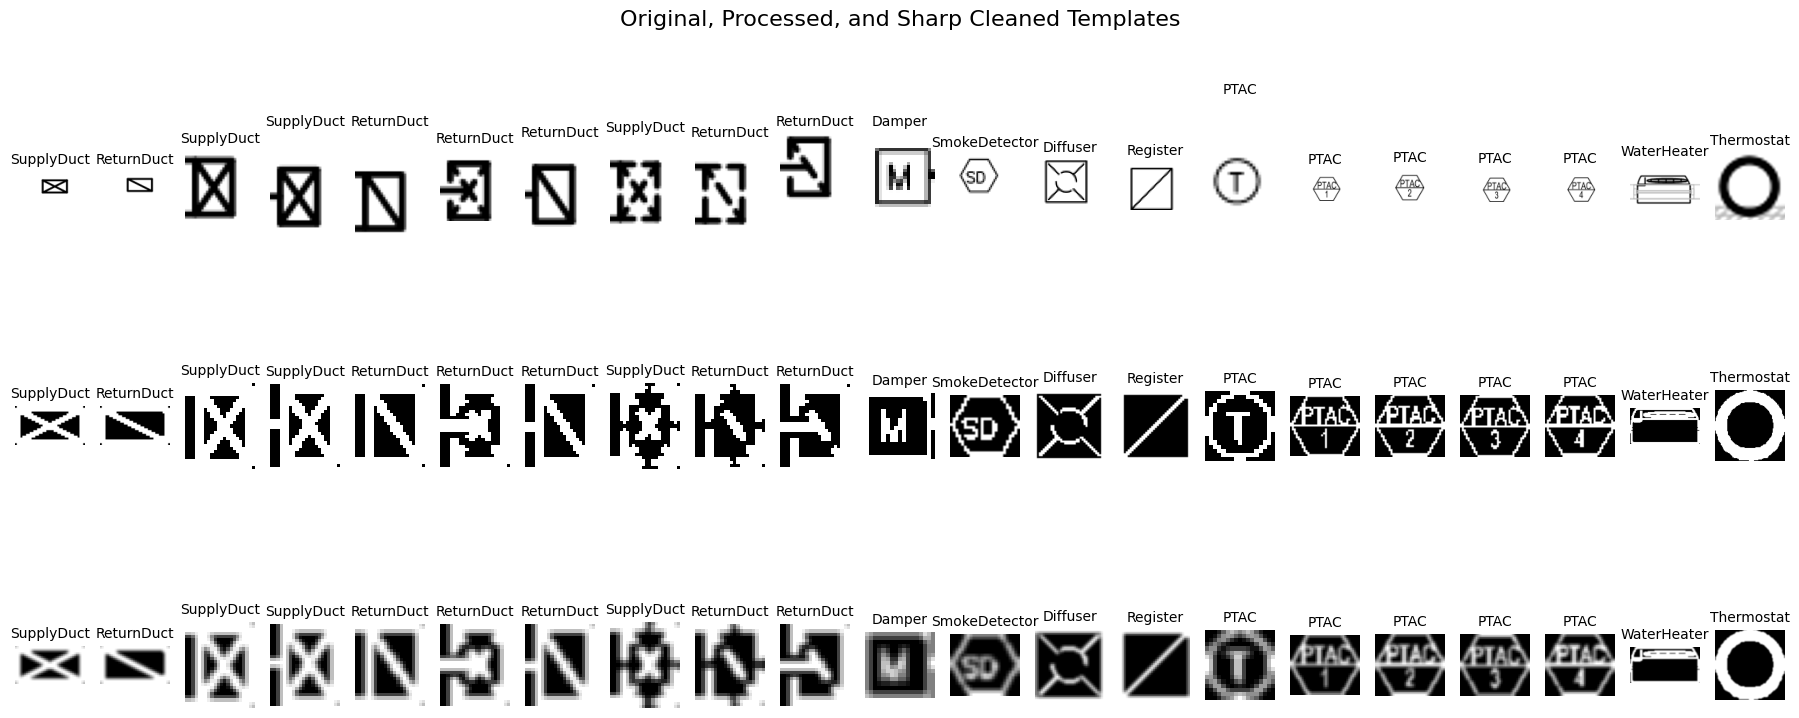

In [ ]:
# Define a refined function to clean up noise while retaining sharpness
def refined_clean_template(template, kernel_size=(3, 3), min_area=10, blur_kernel=(2, 2)):
    """
    Cleans up noise in the template with minimal dilation and sharpens the edges.
    :param template: Input binary template (numpy array)
    :param kernel_size: Size of the kernel for morphological operations
    :param min_area: Minimum area to retain connected components
    :param blur_kernel: Kernel size for Gaussian blur to smooth edges
    :return: Cleaned and sharpened template
    """
    # Create a kernel for morphological operations
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)

    # Perform morphological closing to fill small gaps
    cleaned_template = cv2.morphologyEx(template, cv2.MORPH_CLOSE, kernel)

    # Remove small connected components
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(cleaned_template)
    for i in range(1, num_labels):  # Start from 1 to skip the background
        area = stats[i, cv2.CC_STAT_AREA]
        if area < min_area:
            cleaned_template[labels == i] = 0  # Remove small components

    # Apply GaussianBlur to smooth edges slightly
    if blur_kernel != (0, 0):
        cleaned_template = cv2.GaussianBlur(cleaned_template, blur_kernel, 0)

    return cleaned_template

# Clean up processed templates with refined settings
sharp_cleaned_templates = [
    refined_clean_template(template, kernel_size=(1, 1), min_area=8, blur_kernel=(3, 3))
    for template in processed_templates
]

# Visualize the refined cleaned templates
plt.figure(figsize=(18, 8))  # Adjust the size for better display

# Display original templates (Row 1)
for i, (template, name) in enumerate(zip(original_templates, template_names)):
    if template is not None:
        plt.subplot(3, n_templates, i + 1)
        plt.imshow(template, cmap='gray')
        plt.title(f"{name}", fontsize=10)
        plt.axis('off')

# Display processed templates (Row 2)
for i, (template, name) in enumerate(zip(processed_templates, template_names)):
    if template is not None:
        plt.subplot(3, n_templates, n_templates + i + 1)
        plt.imshow(template, cmap='gray')
        plt.title(f"{name}", fontsize=10)
        plt.axis('off')

# Display sharp cleaned templates (Row 3)
for i, (template, name) in enumerate(zip(sharp_cleaned_templates, template_names)):
    if template is not None:
        plt.subplot(3, n_templates, 2 * n_templates + i + 1)
        plt.imshow(template, cmap='gray')
        plt.title(f"{name}", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.suptitle("Original, Processed, and Sharp Cleaned Templates", fontsize=16, y=1.02)
plt.show()


In [ ]:
# Function to crop the non-zero region of the image
def crop_to_nonzero(image):
    # Find all non-zero coordinates
    coords = cv2.findNonZero(image)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped_image = image[y:y + h, x:x + w]
        return cropped_image
    return image  # Return the original image if no non-zero region is found

# Define a function to preprocess templates and extract contours at specific 90-degree angles
def template_rotations(template_img, rotation_angles=[0, 90, 180, 270]):
    rotated_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        center = (w // 2, h // 2)
        # Compute the diagonal length to create a larger canvas
        diagonal = int(np.sqrt(h**2 + w**2))
        canvas_size = (diagonal, diagonal)
        center = (diagonal // 2, diagonal // 2)

        # Pad the template to fit the new canvas size
        padded_template = cv2.copyMakeBorder(template_img,
                                             top=(diagonal - h) // 2,
                                             bottom=(diagonal - h) // 2,
                                             left=(diagonal - w) // 2,
                                             right=(diagonal - w) // 2,
                                             borderType=cv2.BORDER_CONSTANT,
                                             value=0)

        # Compute the rotation matrix
        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        # Rotate the padded template
        rotated_template = cv2.warpAffine(padded_template, M, canvas_size)

        # Crop to remove the whitespace
        cropped_template = crop_to_nonzero(rotated_template)

        # Store the cropped template
        rotated_templates.append(cropped_template)
    return rotated_templates

# Parameters for visualization
images_per_row = 6  # Max images per row
n_templates_cleaned = len(sharp_cleaned_templates)

# Calculate rows for visualization
n_rows_cleaned = (n_templates_cleaned + images_per_row - 1) // images_per_row

# Visualization for sharp and cleaned templates
plt.figure(figsize=(20, n_rows_cleaned * 3))
plt.suptitle("Sharp and Cleaned Templates", fontsize=20, y=1.02)

for i, (template, name) in enumerate(zip(sharp_cleaned_templates, template_names)):
    if template is not None:
        row = i // images_per_row
        col = i % images_per_row
        plt.subplot(n_rows_cleaned, images_per_row, row * images_per_row + col + 1)
        plt.imshow(template, cmap='gray')
        plt.title(f"{name}\nSize: {template.shape[1]}x{template.shape[0]}", fontsize=10)
        plt.axis('off')

plt.tight_layout()
plt.show()


NameError: name 'sharp_cleaned_templates' is not defined

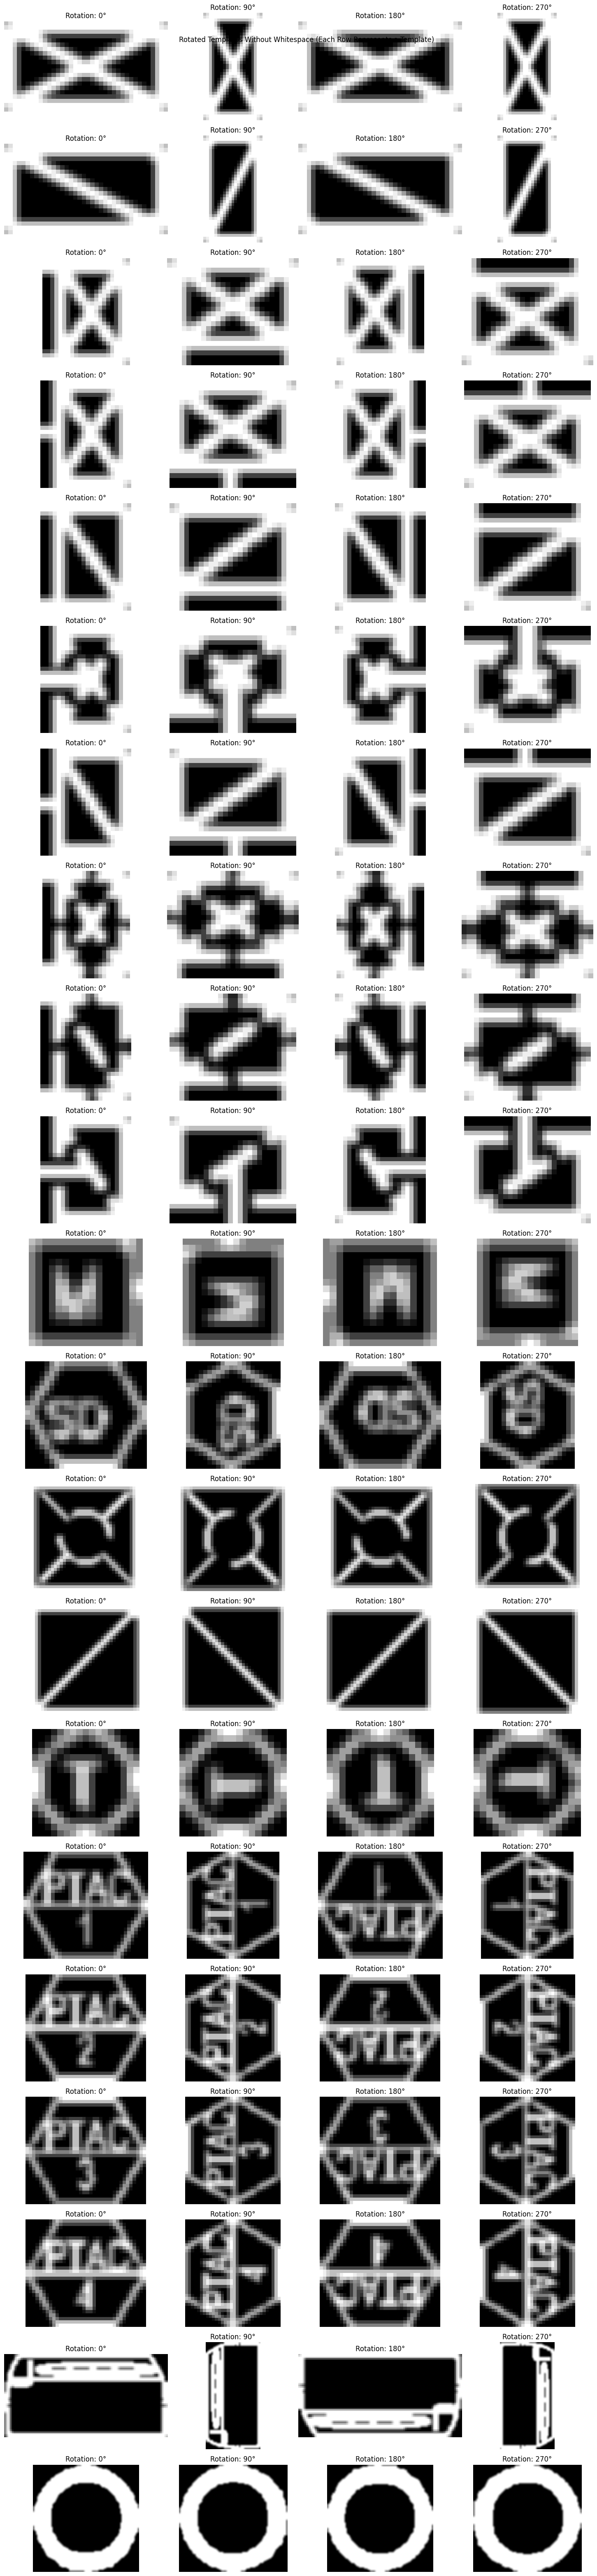

In [ ]:
# Preprocess and store rotated templates
all_template_variants = []
for template in sharp_cleaned_templates:
    if template is not None:
        rotated_templates = template_rotations(template, rotation_angles=[0, 90, 180, 270])
        all_template_variants.append(rotated_templates)

# Visualize rotated templates without whitespace
fig, axes = plt.subplots(len(all_template_variants), 4, figsize=(15, len(all_template_variants) * 3))
fig.suptitle("Rotated Templates Without Whitespace (Each Row Represents a Template)")

for row_idx, rotated_templates in enumerate(all_template_variants):
    for col_idx, rotated_template in enumerate(rotated_templates):
        ax = axes[row_idx, col_idx]
        ax.imshow(rotated_template, cmap='gray')
        ax.axis('off')
        ax.set_title(f"Rotation: {col_idx * 90}°")

plt.tight_layout()
plt.show()

Invariant-Template-Matching: https://github.com/cozheyuanzhangde/Invariant-TemplateMatching

In [ ]:
# IoU Calculation Function
def calculate_iou(box1, box2):
    """Calculate IoU between two bounding boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    inter_area = inter_width * inter_height

    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = inter_area / (area_box1 + area_box2 - inter_area + 1e-6)  # Avoid division by zero
    return iou

def non_max_suppression_with_scores(boxes, scores, iou_threshold=0.5):
    """
    Perform Non-Maximum Suppression (NMS) on bounding boxes with scores.

    Args:
        boxes (list or ndarray): List/Array of bounding boxes in (x1, y1, x2, y2) format.
        scores (list or ndarray): Corresponding confidence scores for the bounding boxes.
        iou_threshold (float): IoU threshold to suppress overlapping boxes.

    Returns:
        selected_boxes (ndarray): Array of selected bounding boxes.
        selected_scores (ndarray): Array of corresponding scores for selected boxes.
    """
    if len(boxes) == 0:
        return [], []

    # Convert to numpy arrays
    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)

    # Sort boxes by scores in descending order
    sorted_indices = np.argsort(scores)[::-1]

    selected_boxes = []
    selected_scores = []

    while len(sorted_indices) > 0:
        # Select the highest-scoring box
        current_index = sorted_indices[0]
        selected_boxes.append(boxes[current_index])
        selected_scores.append(scores[current_index])

        # Compute IoUs with remaining boxes
        current_box = boxes[current_index]
        remaining_boxes = boxes[sorted_indices[1:]]
        ious = np.array([calculate_iou(current_box, box) for box in remaining_boxes])

        # Keep indices of boxes with IoU <= threshold
        sorted_indices = sorted_indices[np.where(ious <= iou_threshold)[0] + 1]

    # Convert to numpy arrays and return
    return np.array(selected_boxes, dtype=np.int32), np.array(selected_scores, dtype=np.float32)

def remove_intersections(boxes, scores=None, iou_threshold=0.5):
    """Remove intersecting bounding boxes using IoU threshold."""
    if scores is None:
        scores = [1] * len(boxes)

    non_intersecting_boxes = []
    non_intersecting_scores = []

    for i, current_box in enumerate(boxes):
        keep = True
        for j, other_box in enumerate(non_intersecting_boxes):
            if calculate_iou(current_box, other_box) > iou_threshold:
                if scores[i] > non_intersecting_scores[j]:
                    # Replace the suppressed box with the current higher-score box
                    non_intersecting_boxes[j] = current_box
                    non_intersecting_scores[j] = scores[i]
                keep = False
                break

        if keep:
            non_intersecting_boxes.append(current_box)
            non_intersecting_scores.append(scores[i])

    return non_intersecting_boxes, non_intersecting_scores

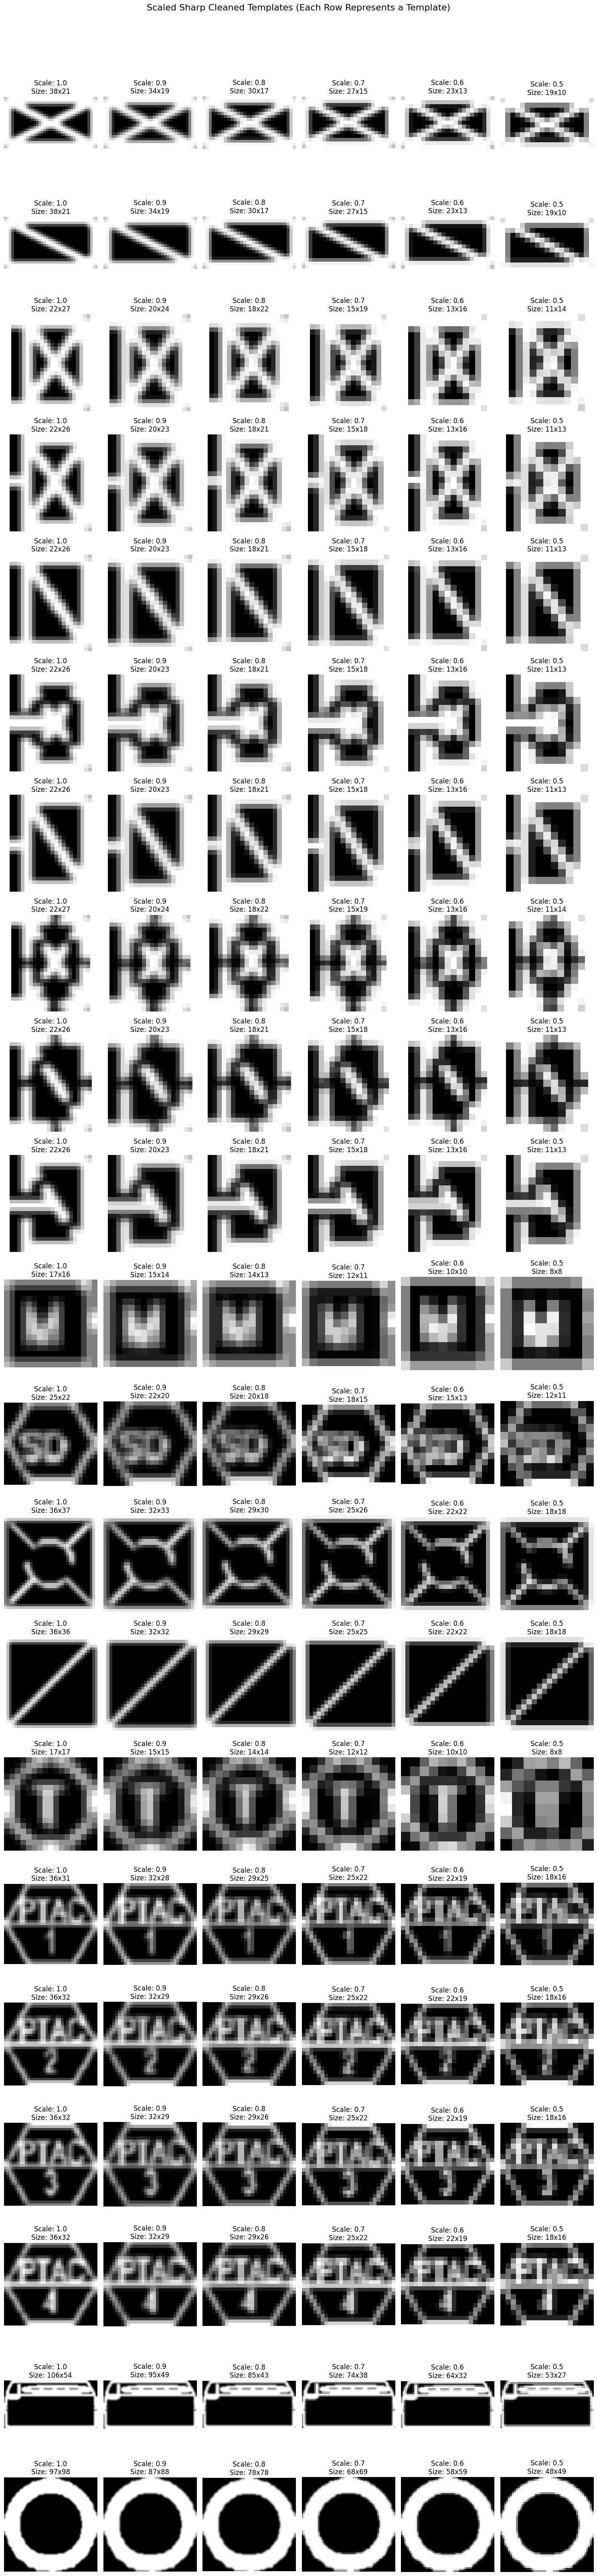

In [ ]:
# Define scales for template resizing
scales = [1.0, 0.9, 0.8, 0.7, 0.6, 0.5]

# Generate scaled versions of sharp cleaned templates
scaled_templates_collection = []
for template in sharp_cleaned_templates:
    if template is not None:
        scaled_templates = [
            cv2.resize(template, None, fx=scale, fy=scale, interpolation=cv2.INTER_LINEAR)
            for scale in scales
        ]
        scaled_templates_collection.append(scaled_templates)

# Visualize scaled templates for each cleaned template
fig, axes = plt.subplots(len(scaled_templates_collection), len(scales), figsize=(15, len(scaled_templates_collection) * 3))
fig.suptitle("Scaled Sharp Cleaned Templates (Each Row Represents a Template)", fontsize=16, y=1.02)

for row_idx, scaled_templates in enumerate(scaled_templates_collection):
    for col_idx, (scale, scaled_template) in enumerate(zip(scales, scaled_templates)):
        ax = axes[row_idx, col_idx]
        ax.imshow(scaled_template, cmap='gray')
        ax.axis('off')
        ax.set_title(f"Scale: {scale}\nSize: {scaled_template.shape[1]}x{scaled_template.shape[0]}")

plt.tight_layout()
plt.show()

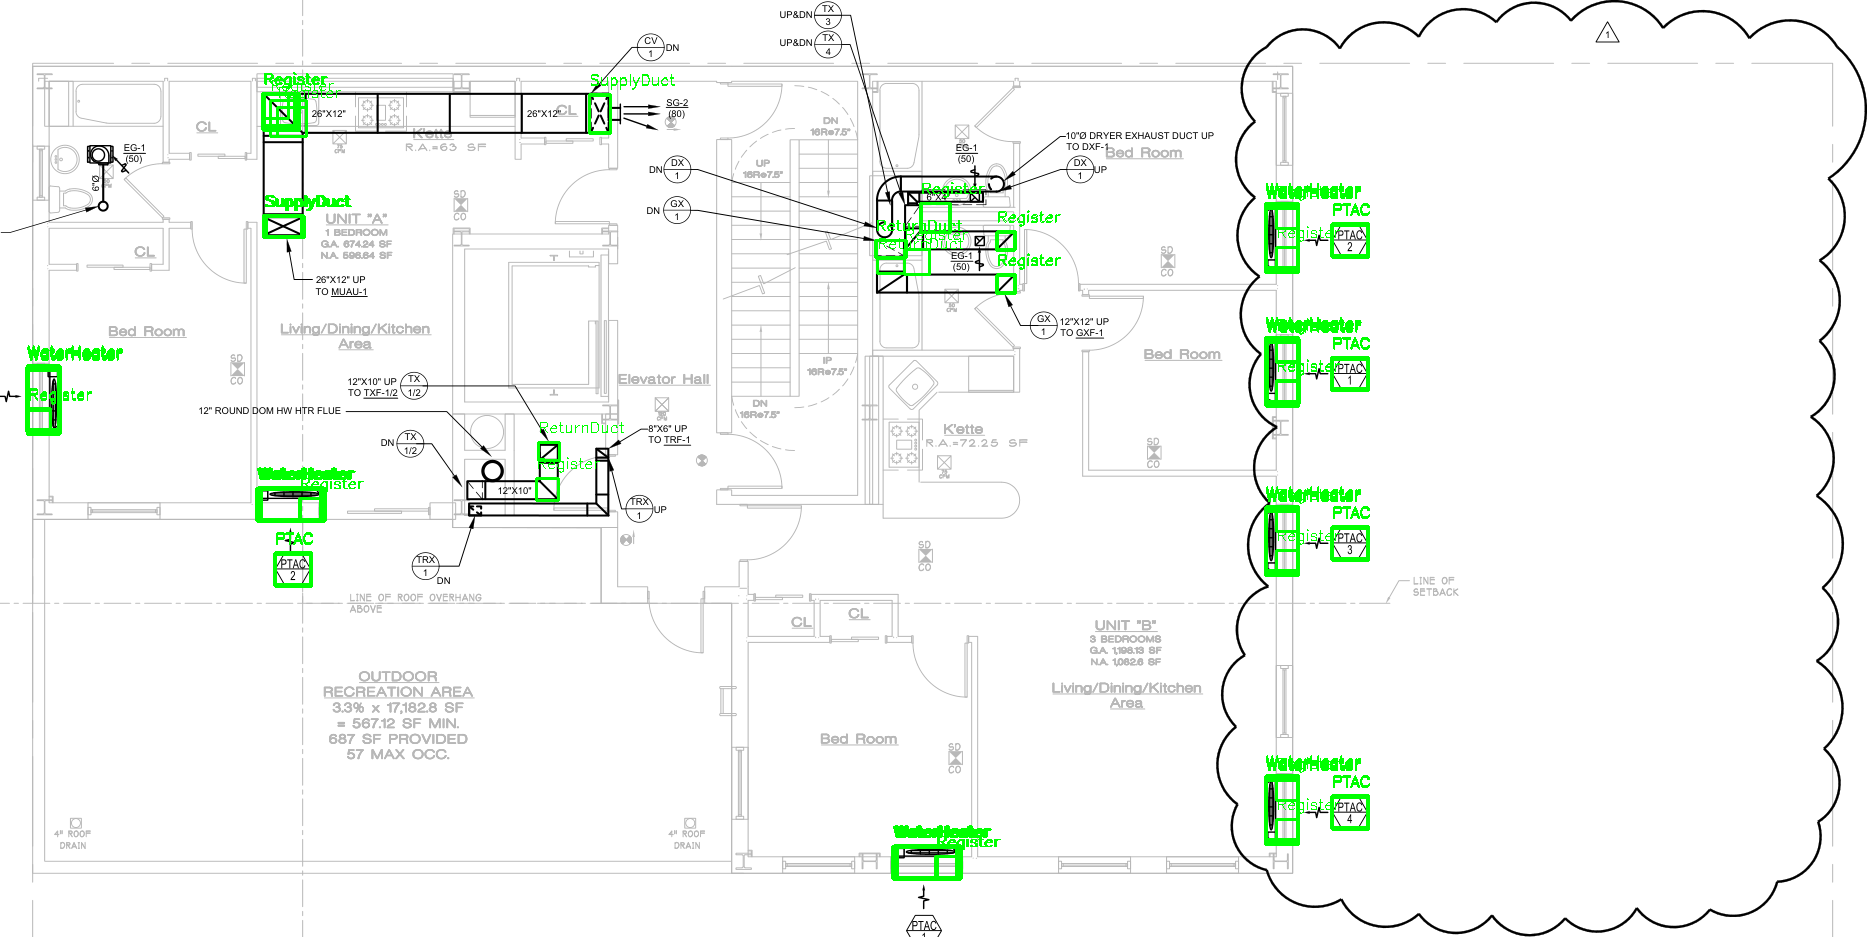

In [ ]:
# Assign thresholds
threshold = 0.75
iou_threshold = 0.2

# Define colors for each unique template
template_colors = {
    "SupplyDuct": (255, 0, 0),  # Red
    "ReturnDuct": (0, 255, 0),  # Green
    "PTAC": (0, 0, 255),  # Blue
    "WaterHeater": (255, 255, 0),  # Yellow
    "Thermostat": (255, 0, 255),  # Magenta
    "Damper": (0, 255, 255),  # Cyan
    "Diffuser": (255, 165, 0),  # Orange
    "Register": (128, 0, 128),  # Purple
    "SmokeDetector": (128, 128, 0)  # Olive
}

# Initialize the dictionary to store predicted bounding boxes
predicted_boxes = {
    "SupplyDuct": [],
    "ReturnDuct": [],
    "PTAC": [],
    "WaterHeater": [],
    "Thermostat": [],
    "Damper": [],
    "Diffuser": [],
    "Register": [],
    "SmokeDetector": []
}


# Initialize storage for unique template matches and scores
unique_template_matches = defaultdict(list)
template_scores = defaultdict(list)

# Debugging: Track total matches and skipped matches
total_matches = 0
total_skipped_matches = 0

# Loop through each set of template variants
for template_variants, template_name in zip(all_template_variants, template_names):
    for scaled_template in template_variants:  # Each item in template_variants is a rotated template
        for scale in scales:
            # Resize the scaled template
            scaled_template_resized = cv2.resize(scaled_template, (0, 0), fx=scale, fy=scale)
            (h, w) = scaled_template_resized.shape[:2]

            # Perform template matching
            result = cv2.matchTemplate(dilated, scaled_template_resized, cv2.TM_CCOEFF_NORMED)
            (yCoords, xCoords) = np.where(result >= threshold)

            for (x, y) in zip(xCoords, yCoords):
                score = result[y, x]  # Confidence score

                # Ensure the bounding box matches the scaled template
                bbox_start_x = int(x)
                bbox_start_y = int(y)
                bbox_end_x = int(x + w)
                bbox_end_y = int(y + h)

                # Check if bounding box fits within the image
                if bbox_end_x <= dilated.shape[1] and bbox_end_y <= dilated.shape[0]:
                    # Store matches and scores
                    unique_template_matches[template_name].append([bbox_start_x, bbox_start_y, bbox_end_x, bbox_end_y])
                    template_scores[template_name].append(score)
                    total_matches += 1
                else:
                    total_skipped_matches += 1

# Create a copy of the image to draw matches
image_with_matches = img.copy()

# Loop through each template type and its matches
for template_name, boxes in unique_template_matches.items():
    color = template_colors.get(template_name.lower(), (0, 255, 0))  # Default to green if undefined
    for (startX, startY, endX, endY) in boxes:
        width, height = endX - startX, endY - startY
        # Ensure valid coordinates
        if startX >= 0 and startY >= 0 and endX <= image_with_matches.shape[1] and endY <= image_with_matches.shape[0]:
            cv2.rectangle(image_with_matches, (startX, startY), (endX, endY), color, 2)
            cv2.putText(image_with_matches, template_name, (startX, startY - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Display the image with all matches
cv2_imshow(image_with_matches)



[DEBUG] Filtered Matches After NMS (Formatted):
PTAC bounding boxes: [[1332, 358, 36, 31], [275, 553, 36, 32], [1332, 796, 36, 32], [1332, 527, 36, 32], [1332, 225, 36, 31]]
WaterHeater bounding boxes: [[895, 846, 64, 32], [258, 488, 64, 32], [27, 367, 32, 64], [1266, 778, 32, 64], [1266, 339, 32, 64], [1266, 206, 32, 64], [1266, 509, 32, 64]]
SupplyDuct bounding boxes: [[264, 216, 38, 21], [589, 94, 21, 38]]
Register bounding boxes: [[263, 93, 32, 32], [536, 478, 22, 22], [996, 275, 18, 18], [904, 249, 25, 25], [997, 231, 18, 18], [920, 203, 29, 29]]
ReturnDuct bounding boxes: [[538, 442, 21, 18], [876, 240, 30, 17], [877, 258, 27, 15]]


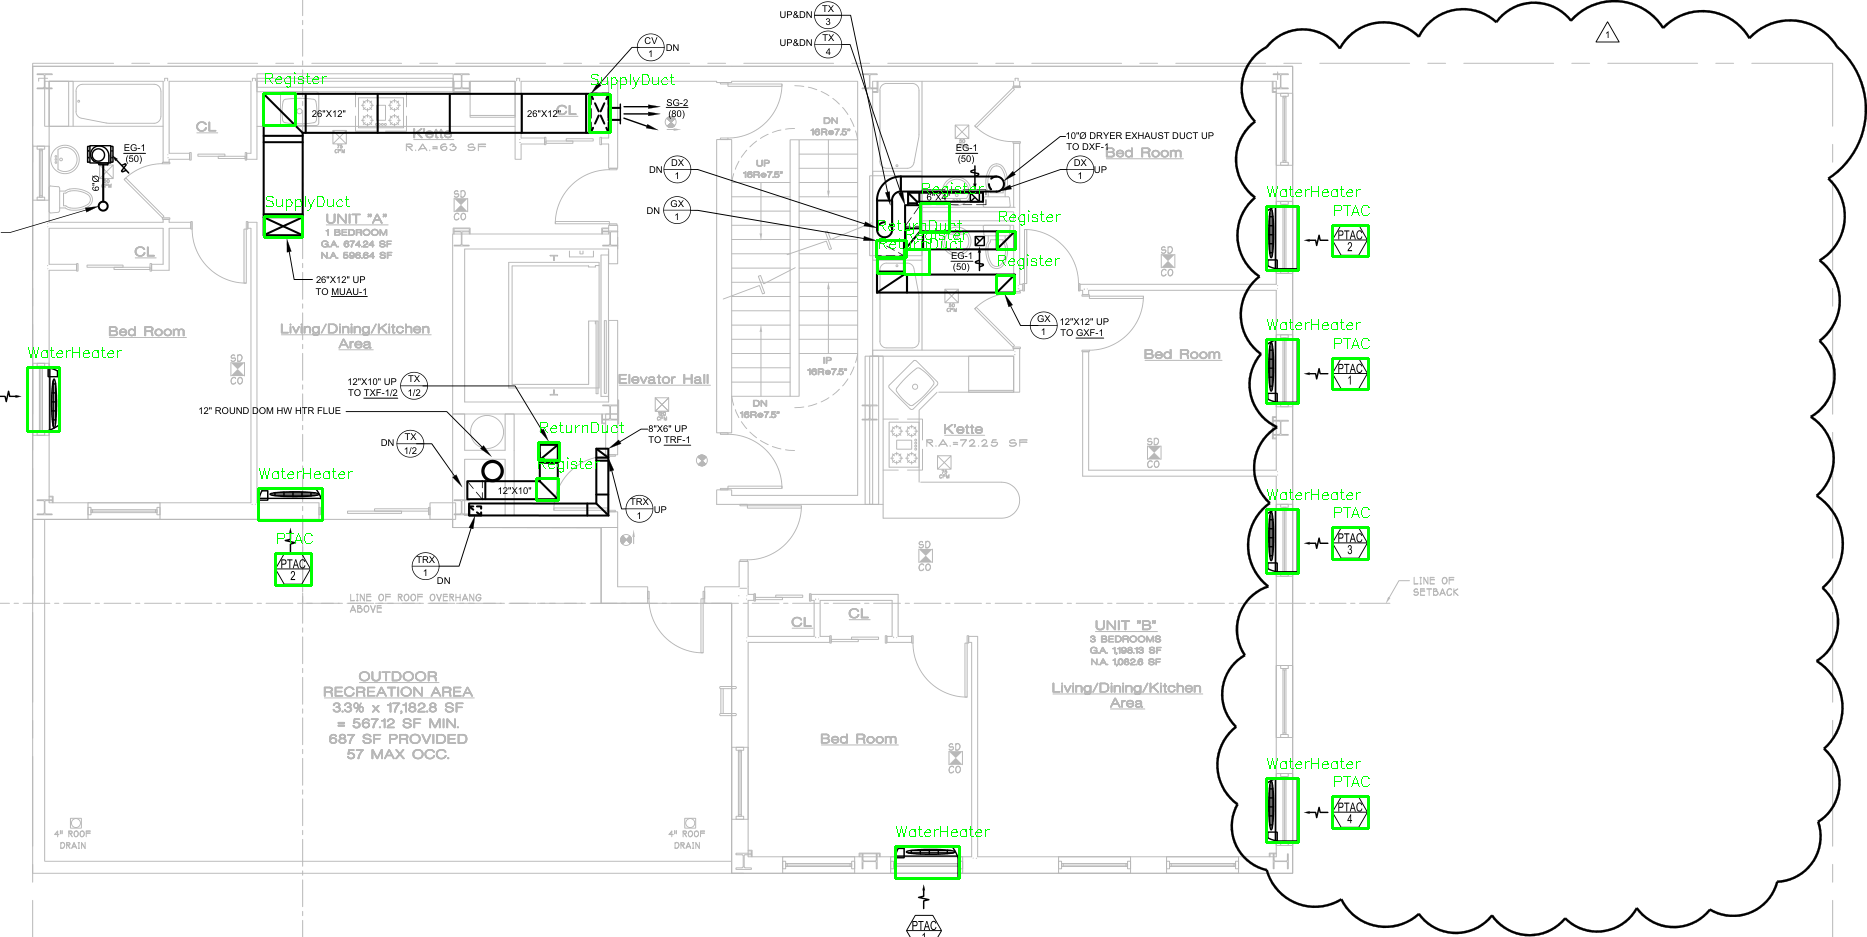

In [ ]:
# Perform NMS-like filtering across all templates
filtered_boxes = []
filtered_template_names = []

# Flatten all boxes and their corresponding template names into a single list
all_boxes = []
all_scores = []
all_template_names = []

for template_name, boxes in unique_template_matches.items():
    for i, box in enumerate(boxes):
        all_boxes.append(box)
        all_scores.append(template_scores[template_name][i])
        all_template_names.append(template_name)

# Convert to numpy arrays with proper formatting
all_boxes = np.array(all_boxes, dtype=np.float32)  # Ensure numeric format
all_scores = np.array(all_scores, dtype=np.float32)
all_template_names = np.array(all_template_names)

# Sort boxes by their scores in descending order
sorted_indices = np.argsort(all_scores)[::-1]
all_boxes = all_boxes[sorted_indices]
all_template_names = all_template_names[sorted_indices]

# Perform Non-Maximum Suppression
while len(all_boxes) > 0:
    # Pick the box with the highest score
    selected_box = all_boxes[0]
    selected_template_name = all_template_names[0]
    filtered_boxes.append(selected_box)
    filtered_template_names.append(selected_template_name)

    # Compute IoU for the selected box with all remaining boxes
    ious = np.array([calculate_iou(selected_box, other_box) for other_box in all_boxes[1:]])

    # Remove boxes with IoU above the threshold
    remaining_indices = np.where(ious <= iou_threshold)[0] + 1  # Offset by 1 due to slicing
    all_boxes = all_boxes[remaining_indices]
    all_template_names = all_template_names[remaining_indices]

# Group filtered matches by template type
filtered_matches_grouped = defaultdict(list)
for template_name, box in zip(filtered_template_names, filtered_boxes):
    # Convert to (x, y, w, h) format
    x, y, x2, y2 = map(int, box)
    filtered_matches_grouped[template_name].append([x, y, x2 - x, y2 - y])

# Print filtered matches in the required format
print("\n[DEBUG] Filtered Matches After NMS (Formatted):")
for template_name, boxes in filtered_matches_grouped.items():
    print(f"{template_name} bounding boxes: {boxes}")

# Visualizing the filtered matches
filtered_image = img.copy()

for template_name, (startX, startY, endX, endY) in zip(filtered_template_names, filtered_boxes):
    color = template_colors.get(template_name.lower(), (0, 255, 0))
    # Convert coordinates to integers
    startX, startY, endX, endY = int(startX), int(startY), int(endX), int(endY)
    cv2.rectangle(filtered_image, (startX, startY), (endX, endY), color, 2)
    cv2.putText(filtered_image, template_name, (startX, startY - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

# Display the filtered image
cv2_imshow(filtered_image)


Evaluate object detection using ground-truth-labeled image from MATLAB image labeler.

In [ ]:
# Load the .mat file
mat_data = loadmat(mat_file_path)

# Inspect the keys to identify the structure
print("Keys in the .mat file:", mat_data.keys())

# Extract the struct
labels_struct = mat_data['labelsStruct']  # Adjust based on the key name

# Parse bounding boxes for each label type
def parse_bounding_boxes(bbox_array):
    """Converts MATLAB bounding boxes to Python-friendly lists."""
    if bbox_array.size == 0:
        return []  # Return empty if no bounding boxes
    if isinstance(bbox_array, np.ndarray):
        # Case 1: Directly in (N, 4) format
        if bbox_array.ndim == 2 and bbox_array.shape[1] == 4:
            return bbox_array.tolist()
        # Case 2: Single bounding box as a flat array (e.g., [x, y, width, height])
        elif bbox_array.ndim == 1 and bbox_array.size == 4:
            return [bbox_array.tolist()]
        # Case 3: Nested or irregular single bounding box
        elif bbox_array.ndim == 2 and bbox_array.shape[0] == 1 and bbox_array.shape[1] == 1:
            # Drill down into the nested array and reshape
            nested_bbox = bbox_array[0, 0]
            if nested_bbox.ndim == 1 and nested_bbox.size == 4:
                return [nested_bbox.tolist()]
            elif nested_bbox.ndim == 2 and nested_bbox.shape[1] == 4:
                return nested_bbox.tolist()
        # Case 4: Reshape flat array into (N, 4)
        try:
            return bbox_array.reshape(-1, 4).tolist()
        except ValueError:
            pass  # Fall through to empty return if reshaping fails
    return []  # Default return for unrecognized formats


# Parse ground truth bounding boxes
parsed_labels = []
for row in labels_struct:
    # Safely extract elements, defaulting to None if row[0] is None or incomplete
    if row[0] is not None:
        unpacked = list(row[0]) + [None] * (9 - len(row[0]))  # Ensure all 9 elements
    else:
        unpacked = [None] * 9

    # Assign to corresponding labels
    supply_duct, return_duct, ptac, water_heater, thermostat, damper, diffuser, register, smoke_detector = unpacked

    # Append parsed labels for each type
    parsed_labels.append({
        "SupplyDuct": parse_bounding_boxes(supply_duct) if supply_duct is not None else [],
        "ReturnDuct": parse_bounding_boxes(return_duct) if return_duct is not None else [],
        "PTAC": parse_bounding_boxes(ptac) if ptac is not None else [],
        "WaterHeater": parse_bounding_boxes(water_heater) if water_heater is not None else [],
        "Thermostat": parse_bounding_boxes(thermostat) if thermostat is not None else [],
        "Damper": parse_bounding_boxes(damper) if damper is not None else [],
        "Diffuser": parse_bounding_boxes(diffuser) if diffuser is not None else [],
        "Register": parse_bounding_boxes(register) if register is not None else [],
        "SmokeDetector": parse_bounding_boxes(smoke_detector) if smoke_detector is not None else []
    })

# Assign the first row's parsed labels to `ground_truth_boxes`
ground_truth_boxes = parsed_labels[0]
supply_duct_boxes = ground_truth_boxes["SupplyDuct"]
return_duct_boxes = ground_truth_boxes["ReturnDuct"]
ptac_boxes = ground_truth_boxes["PTAC"]
water_heater_boxes = ground_truth_boxes["WaterHeater"]
thermostat_boxes = ground_truth_boxes["Thermostat"]
damper_boxes = ground_truth_boxes["Damper"]
diffuser_boxes = ground_truth_boxes["Diffuser"]
register_boxes = ground_truth_boxes["Register"]
smoke_detector_boxes = ground_truth_boxes["SmokeDetector"]

# Display parsed bounding boxes
print("\n[DEBUG] Ground Truth Bounding Boxes:")
print("SupplyDuct bounding boxes:", supply_duct_boxes)
print("ReturnDuct bounding boxes:", return_duct_boxes)
print("PTAC bounding boxes:", ptac_boxes)
print("WaterHeater bounding boxes:", water_heater_boxes)
print("Thermostat bounding boxes:", thermostat_boxes)
print("Damper bounding boxes:", damper_boxes)
print("Diffuser bounding boxes:", diffuser_boxes)
print("Register bounding boxes:", register_boxes)
print("SmokeDetector bounding boxes:", smoke_detector_boxes)


Keys in the .mat file: dict_keys(['__header__', '__version__', '__globals__', 'labelsStruct'])

[DEBUG] Ground Truth Bounding Boxes:
SupplyDuct bounding boxes: [[260, 214, 49, 27], [587, 90, 26, 48]]
ReturnDuct bounding boxes: [[996, 227, 23, 28], [994, 271, 25, 27], [536, 442, 27, 21], [594, 447, 18, 15], [468, 503, 16, 16], [466, 478, 23, 23], [874, 238, 35, 25], [903, 204, 21, 27]]
PTAC bounding boxes: [[24, 365, 43, 68], [252, 487, 81, 41], [276, 552, 38, 35], [889, 839, 76, 44], [1332, 795, 41, 36], [1260, 776, 45, 68], [1332, 528, 38, 35], [1263, 509, 41, 68], [1331, 355, 40, 38], [1264, 338, 40, 70], [1264, 206, 39, 67], [1331, 222, 39, 38]]
WaterHeater bounding boxes: [[480, 460, 27, 23]]
Thermostat bounding boxes: []
Damper bounding boxes: []
Diffuser bounding boxes: []
Register bounding boxes: []
SmokeDetector bounding boxes: []


In [ ]:
print(labels_struct.dtype)


[('SupplyDuct', 'O'), ('ReturnDuct', 'O'), ('PTAC', 'O'), ('WaterHeater', 'O')]


In [ ]:
# Function to calculate IoU
def calculate_iou(gt_box, pred_box):
    """Calculate IoU between two bounding boxes."""
    from shapely.geometry import box  # Local import to ensure `box` is correct

    # Convert ground truth and prediction boxes to Shapely box objects
    gt = box(gt_box[0], gt_box[1], gt_box[0] + gt_box[2], gt_box[1] + gt_box[3])  # Convert (x, y, w, h) to (x1, y1, x2, y2)
    pred = box(pred_box[0], pred_box[1], pred_box[0] + pred_box[2], pred_box[1] + pred_box[3])

    # Calculate intersection and union areas
    intersection = gt.intersection(pred).area
    union = gt.union(pred).area

    # Return IoU
    return intersection / union if union > 0 else 0


# Function to match predictions to ground truth
def match_predictions(gt_boxes, pred_boxes, iou_threshold):
    matches = []
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                matches.append((gt, pred, iou))
    return matches

# Function to calculate precision and recall for a single label type
def calculate_precision_recall(gt_boxes, pred_boxes, iou_threshold):
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)
    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    return precision, recall

# Function to calculate total metrics
def calculate_total_metrics(gt_boxes, pred_boxes, iou_threshold):
    total_true_matches = 0
    total_ground_truth = sum(len(gt) for gt in gt_boxes.values())
    total_predictions = sum(len(pred) for pred in pred_boxes.values())
    tp, fp, fn = 0, 0, 0
    mismatches = 0

    for gt, pred in zip(gt_boxes.values(), pred_boxes.values()):
        matched_gt = set()
        for pred_box in pred:
            matched = False
            for i, gt_box in enumerate(gt):
                if calculate_iou(gt_box, pred_box) >= iou_threshold and i not in matched_gt:
                    tp += 1
                    matched_gt.add(i)
                    matched = True
                    break
            if not matched:
                fp += 1
        fn += len(gt) - len(matched_gt)
    mismatches = fp
    return total_true_matches, total_ground_truth, total_predictions, tp, fp, fn, mismatches

# Function to calculate mean Average Precision (mAP)
def calculate_map(gt_boxes, pred_boxes, iou_threshold):
    matches = match_predictions(gt_boxes, pred_boxes, iou_threshold)
    true_positives = len(matches)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives
    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    ap = (precision + recall) / 2 if precision > 0 or recall > 0 else 0
    return ap

# Draw bounding boxes
def draw_boxes(image, boxes, color, label):
    for box in boxes:
        x, y, w, h = box
        cv2.rectangle(image, (x, y), (x + w, y + h), color, 2)
        cv2.putText(image, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

# Annotate IoU
def annotate_iou(image, gt_boxes, pred_boxes, color, iou_threshold):
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                cv2.putText(
                    image, f"IoU: {iou:.2f}", (pred[0], pred[1] - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2
                )


[DEBUG] Predicted Boxes (Filtered by NMS):
PTAC: [[1332, 358, 36, 31], [275, 553, 36, 32], [1332, 796, 36, 32], [1332, 527, 36, 32], [1332, 225, 36, 31]]
WaterHeater: [[895, 846, 64, 32], [258, 488, 64, 32], [27, 367, 32, 64], [1266, 778, 32, 64], [1266, 339, 32, 64], [1266, 206, 32, 64], [1266, 509, 32, 64]]
SupplyDuct: [[264, 216, 38, 21], [589, 94, 21, 38]]
Register: [[263, 93, 32, 32], [536, 478, 22, 22], [996, 275, 18, 18], [904, 249, 25, 25], [997, 231, 18, 18], [920, 203, 29, 29]]
ReturnDuct: [[538, 442, 21, 18], [876, 240, 30, 17], [877, 258, 27, 15]]


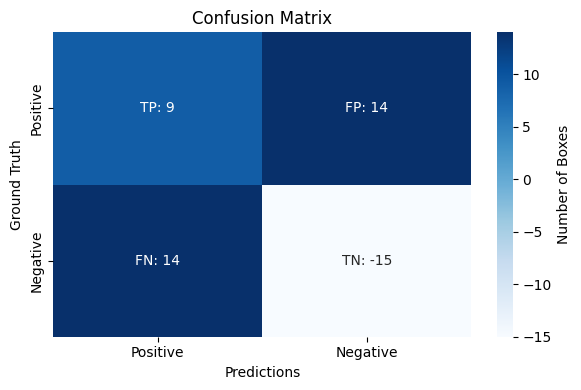

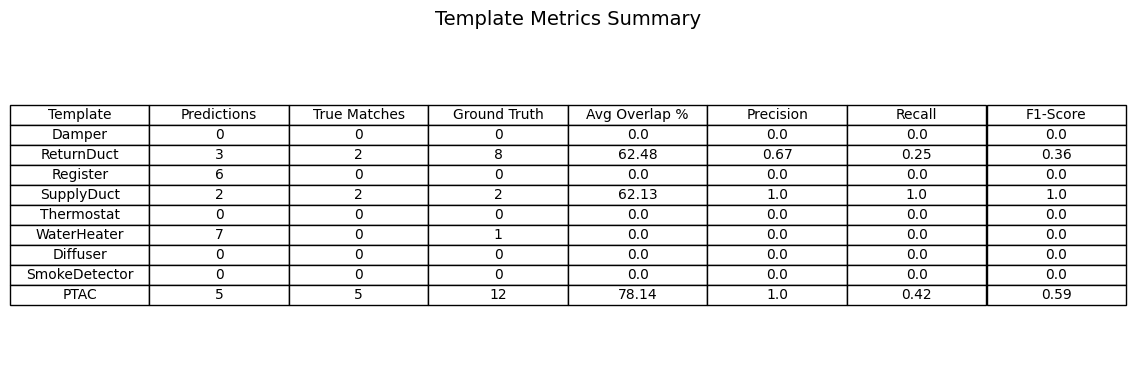

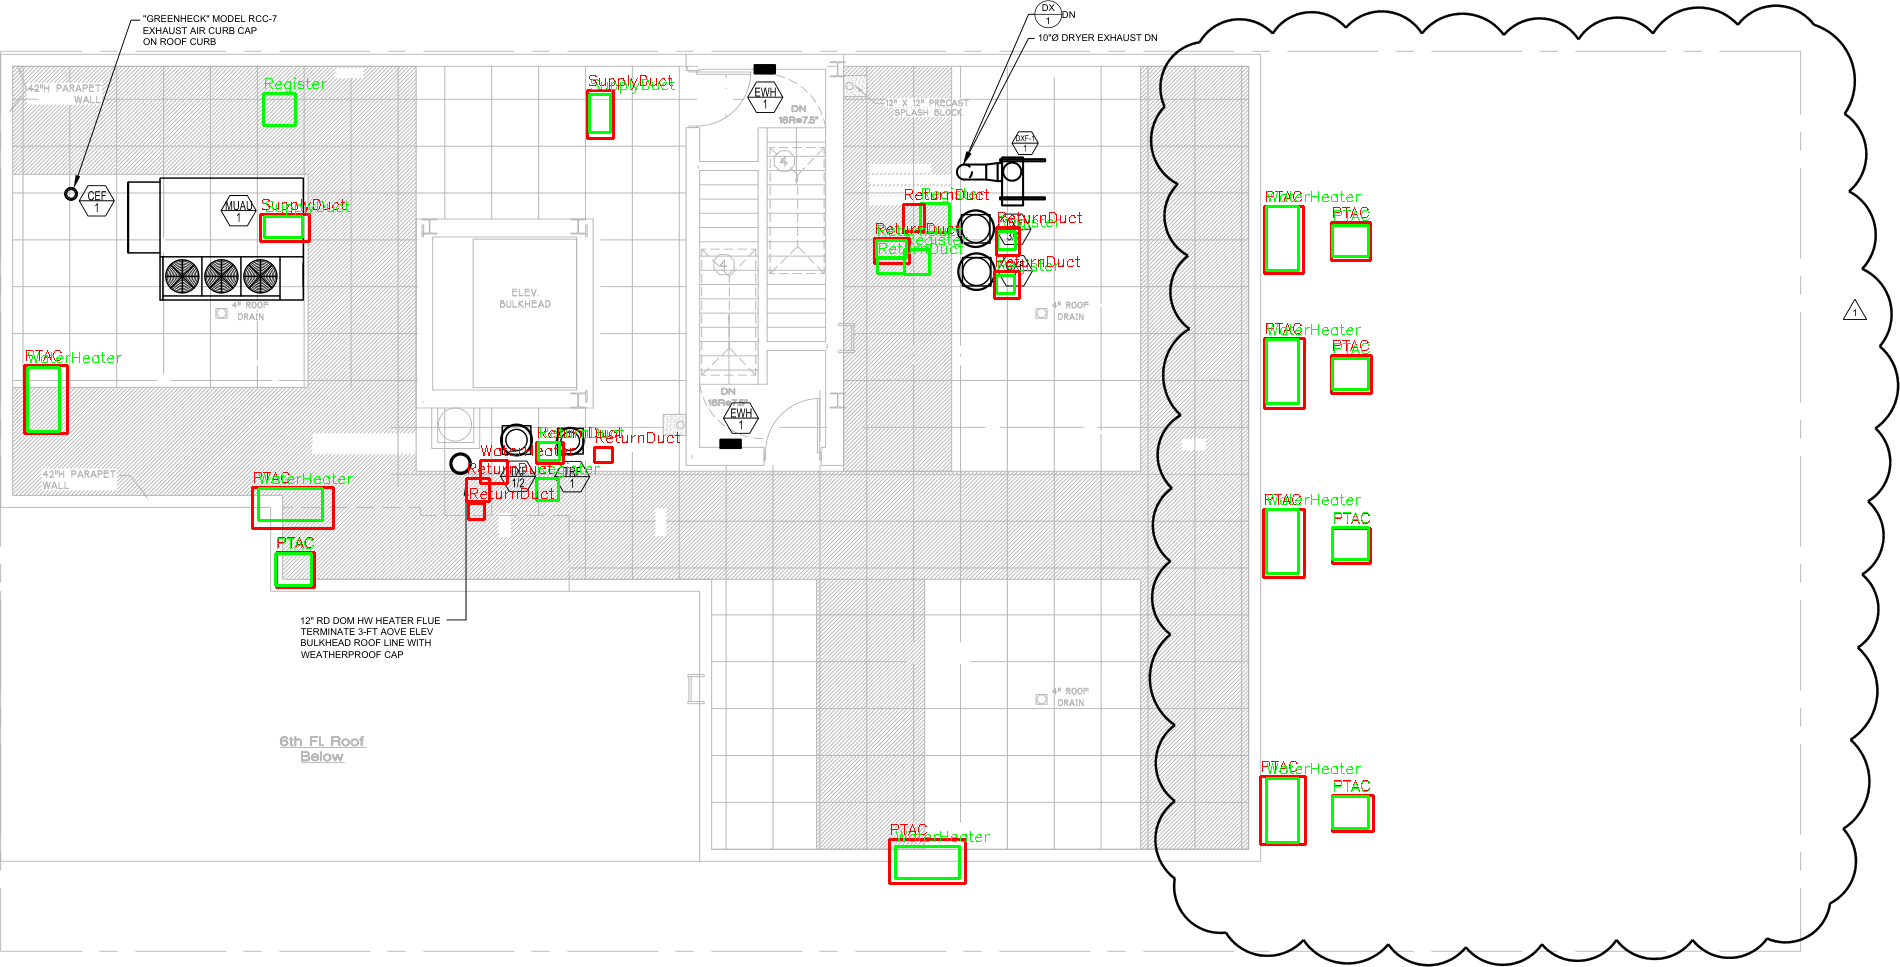

In [ ]:
# Function to calculate IoU
def calculate_iou(gt_box, pred_box):
    """Calculate IoU between two bounding boxes."""
    from shapely.geometry import box
    gt = box(gt_box[0], gt_box[1], gt_box[0] + gt_box[2], gt_box[1] + gt_box[3])
    pred = box(pred_box[0], pred_box[1], pred_box[0] + pred_box[2], pred_box[1] + pred_box[3])
    intersection = gt.intersection(pred).area
    union = gt.union(pred).area
    return intersection / union if union > 0 else 0

# Initialize filtered predicted boxes after NMS
predicted_boxes = defaultdict(list)

# Populate filtered predicted boxes
for template_name, boxes in filtered_matches_grouped.items():
    for box in boxes:
        x, y, w, h = map(int, box)
        predicted_boxes[template_name].append([x, y, w, h])

# Debugging: Display filtered predicted boxes
print("\n[DEBUG] Predicted Boxes (Filtered by NMS):")
for label, boxes in predicted_boxes.items():
    print(f"{label}: {boxes}")

# Visualization: Draw bounding boxes
visualized_image = img.copy()  # Replace img with your input image
colors = {
    "Actual": (0, 0, 255),  # Red for ground truth
    "Predicted": (0, 255, 0),  # Green for predicted boxes
}

# Draw bounding boxes for all templates
for label_type in predicted_boxes.keys():
    gt_boxes = ground_truth_boxes.get(label_type, [])  # Ground truth boxes
    pred_boxes = predicted_boxes.get(label_type, [])  # Predicted boxes

    # Draw ground truth (red)
    for gt_box in gt_boxes:
        x, y, w, h = map(int, gt_box)
        cv2.rectangle(visualized_image, (x, y), (x + w, y + h), colors["Actual"], 2)
        cv2.putText(visualized_image, f"{label_type}", (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors["Actual"], 1)

    # Draw predictions (green)
    for pred_box in pred_boxes:
        x, y, w, h = map(int, pred_box)
        cv2.rectangle(visualized_image, (x, y), (x + w, y + h), colors["Predicted"], 2)
        cv2.putText(visualized_image, f"{label_type}", (x, y - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, colors["Predicted"], 1)

# Generate confusion matrix and other metrics
tp, fp, fn = 0, 0, 0
iou_threshold = 0.5  # Use a standard IoU threshold
for label_type in predicted_boxes.keys():
    gt_boxes = ground_truth_boxes.get(label_type, [])
    pred_boxes = predicted_boxes.get(label_type, [])
    true_positives = sum(1 for gt in gt_boxes for pred in pred_boxes if calculate_iou(gt, pred) >= iou_threshold)
    false_positives = len(pred_boxes) - true_positives
    false_negatives = len(gt_boxes) - true_positives
    tp += true_positives
    fp += false_positives
    fn += false_negatives

# Generate confusion matrix
conf_matrix = np.array([[tp, fp], [fn, len(gt_boxes) - tp - fn]])

# Modify the annotations to include the labels (TP, FP, FN, TN)
annot = np.array([
    [f"TP: {tp}", f"FP: {fp}"],
    [f"FN: {fn}", f"TN: {len(gt_boxes) - tp - fn}"]
])

# Visualize confusion matrix with annotations
plt.figure(figsize=(6, 4))
sns.heatmap(
    conf_matrix,
    annot=annot,  # Use the custom annotations with labels
    fmt="s",  # String format for custom labels
    cmap="Blues",
    xticklabels=["Positive", "Negative"],
    yticklabels=["Positive", "Negative"],
    cbar_kws={'label': 'Number of Boxes'}
)
plt.title("Confusion Matrix")
plt.xlabel("Predictions")
plt.ylabel("Ground Truth")
plt.tight_layout()
plt.show()


# Add all possible template types (even those with no predictions or ground truth)
all_template_types = set(predicted_boxes.keys()).union(set(ground_truth_boxes.keys()))

# Per-template metrics with "True Matches" and "Avg Overlap %"
template_metrics = []
for label_type in all_template_types:  # Iterate over all template types
    gt_boxes = ground_truth_boxes.get(label_type, [])  # Get ground truth boxes, default to empty
    pred_boxes = predicted_boxes.get(label_type, [])  # Get predicted boxes, default to empty

    # Calculate true matches based on IoU threshold
    true_matches = 0
    overlap_percentages = []
    for gt in gt_boxes:
        for pred in pred_boxes:
            iou = calculate_iou(gt, pred)
            if iou >= iou_threshold:
                true_matches += 1
                overlap_percentages.append(iou)
                break  # Match only one prediction to a ground truth box

    # Metrics calculation
    false_positives = len(pred_boxes) - true_matches
    false_negatives = len(gt_boxes) - true_matches
    precision = round(true_matches / (true_matches + false_positives), 2) if (true_matches + false_positives) > 0 else 0
    recall = round(true_matches / (true_matches + false_negatives), 2) if (true_matches + false_negatives) > 0 else 0
    f1_score = round(2 * precision * recall / (precision + recall), 2) if (precision + recall) > 0 else 0

    # Average overlap percentage
    avg_overlap_percentage = round((sum(overlap_percentages) / len(overlap_percentages)) * 100, 2) if overlap_percentages else 0

    # Append metrics for this template
    template_metrics.append({
        "Template": label_type,
        "Predictions": len(pred_boxes),
        "True Matches": true_matches,
        "Ground Truth": len(gt_boxes),
        "Avg Overlap %": avg_overlap_percentage,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1_score,
    })

# Create a DataFrame for metrics
metrics_table = pd.DataFrame(template_metrics)

# Visualize as a table
fig, ax = plt.subplots(figsize=(12, len(template_metrics) * 0.5))
ax.axis('tight')
ax.axis('off')
tbl = plt.table(
    cellText=metrics_table.values,
    colLabels=metrics_table.columns,
    loc='center',
    cellLoc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.2)
plt.title("Template Metrics Summary", fontsize=14, pad=5)
plt.show()

# Display overall metrics
total_true_matches = sum(row["True Matches"] for row in template_metrics)
total_ground_truth = sum(row["Ground Truth"] for row in template_metrics)
total_predictions = sum(row["Predictions"] for row in template_metrics)
overall_avg_overlap = round(sum(
    row["Avg Overlap %"] * row["True Matches"] for row in template_metrics
) / total_true_matches, 2) if total_true_matches > 0 else 0
overall_precision = round(total_true_matches / total_predictions, 2) if total_predictions > 0 else 0
overall_recall = round(total_true_matches / total_ground_truth, 2) if total_ground_truth > 0 else 0
overall_f1_score = round(2 * overall_precision * overall_recall / (overall_precision + overall_recall), 2) if (overall_precision + overall_recall) > 0 else 0


cv2_imshow(visualized_image)

## IoU Threshold Results

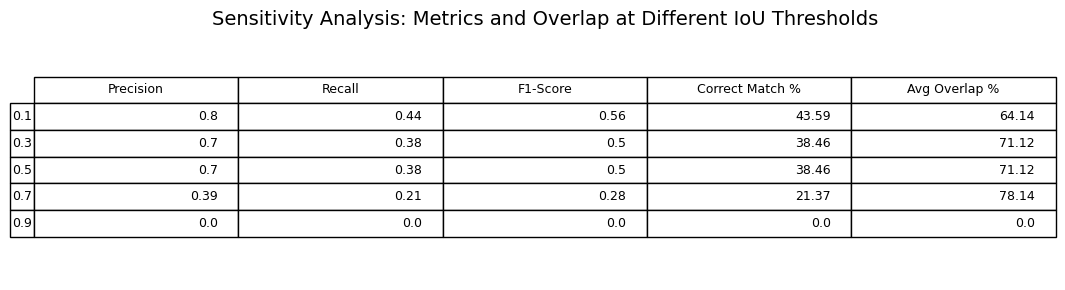

In [ ]:
# IoU thresholds for analysis
iou_thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]

# Initialize a list to store metrics for each threshold
sensitivity_metrics = []

# Function to compute Precision, Recall, and F1-Score
def compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold):
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = 0  # False Negatives

    matched_gt = set()

    for pred_box in predicted_boxes:
        match_found = False
        for i, gt_box in enumerate(ground_truth_boxes):
            if i in matched_gt:  # Skip already matched ground truth boxes
                continue
            iou = calculate_iou(gt_box, pred_box)
            if iou >= iou_threshold:
                tp += 1
                matched_gt.add(i)
                match_found = True
                break
        if not match_found:
            fp += 1

    fn = len(ground_truth_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

# Compute metrics for each IoU threshold
for iou_threshold in iou_thresholds:
    tp, fp, fn = 0, 0, 0
    precision, recall, f1_score = 0, 0, 0
    total_ground_truth = 0  # Track the total number of ground truth labels
    iou_sum = 0  # Sum of IoU values for correctly matched boxes
    match_count = 0  # Count of correctly matched boxes

    # Calculate metrics for all templates at this IoU threshold
    for label_type in template_names:
        gt_boxes = ground_truth_boxes.get(label_type, [])
        pred_boxes = predicted_boxes.get(label_type, [])

        # Match ground truth and predicted boxes
        for pred_box in pred_boxes:
            best_iou = 0
            best_match = None
            for gt_box in gt_boxes:
                iou = calculate_iou(gt_box, pred_box)
                if iou >= iou_threshold and iou > best_iou:
                    best_iou = iou
                    best_match = gt_box
            if best_match:
                iou_sum += best_iou
                match_count += 1

        # Compute metrics
        precision, recall, f1 = compute_metrics(pred_boxes, gt_boxes, iou_threshold)
        true_positives = sum(1 for gt in gt_boxes for pred in pred_boxes if calculate_iou(gt, pred) >= iou_threshold)
        false_positives = len(pred_boxes) - true_positives
        false_negatives = len(gt_boxes) - true_positives

        tp += true_positives
        fp += false_positives
        fn += false_negatives
        total_ground_truth += len(gt_boxes)  # Update total ground truth count

    # Calculate overall precision, recall, and F1-Score for this threshold
    overall_precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    overall_recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    overall_f1_score = (2 * overall_precision * overall_recall) / (overall_precision + overall_recall) if (overall_precision + overall_recall) > 0 else 0
    correct_match_percentage = (tp / total_ground_truth) * 100 if total_ground_truth > 0 else 0  # Percentage of correct matches

    # Calculate average overlap percentage
    average_overlap_percentage = (iou_sum / match_count) * 100 if match_count > 0 else 0

    # Append metrics for this IoU threshold
    sensitivity_metrics.append({
        "Precision": overall_precision,
        "Recall": overall_recall,
        "F1-Score": overall_f1_score,
        "Correct Match %": correct_match_percentage,  # Add the new metric
        "Avg Overlap %": average_overlap_percentage,  # Add average overlap percentage
    })

# Convert to DataFrame
sensitivity_table = pd.DataFrame(sensitivity_metrics, index=iou_thresholds)

# Rename the index to reflect the IoU thresholds
sensitivity_table.index.name = "IoU Threshold"

# Rearrange columns for readability
sensitivity_table = sensitivity_table[["Precision", "Recall", "F1-Score", "Correct Match %", "Avg Overlap %"]]

# Round the DataFrame to 2 decimal places
sensitivity_table = sensitivity_table.round(2)

# Display the sensitivity table with adjusted font size and scaling
fig, ax = plt.subplots(figsize=(12, len(sensitivity_table) * 0.6))  # Adjust size based on table content
ax.axis('tight')
ax.axis('off')

# Create the table with adjusted scaling and font size
tbl = table(
    ax, sensitivity_table, loc='center',
    colWidths=[0.2] * len(sensitivity_table.columns)  # Adjust column width
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)  # Reduced font size for better fit
tbl.scale(1.5, 1.5)  # Adjust scaling for improved readability

# Add a title
plt.title("Sensitivity Analysis: Metrics and Overlap at Different IoU Thresholds", fontsize=14)
plt.tight_layout()
plt.show()


## IoU Threshold Distribtions vs Precision/Recall

*Which IoU threshold value to choose?*

In [ ]:
# Function to compute Precision, Recall, and F1-Score
def compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold):
    tp = 0  # True Positives
    fp = 0  # False Positives
    fn = 0  # False Negatives

    matched_gt = set()

    for pred_box in predicted_boxes:
        match_found = False
        for i, gt_box in enumerate(ground_truth_boxes):
            if i in matched_gt:  # Skip already matched ground truth boxes
                continue
            iou = calculate_iou(gt_box, pred_box)
            if iou >= iou_threshold:
                tp += 1
                matched_gt.add(i)
                match_found = True
                break
        if not match_found:
            fp += 1

    fn = len(ground_truth_boxes) - len(matched_gt)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

# Function to compute IoU distribution
def compute_iou_distribution(predicted_boxes, ground_truth_boxes):
    iou_values = []
    for pred_box in predicted_boxes:
        best_iou = 0
        for gt_box in ground_truth_boxes:
            iou = calculate_iou(gt_box, pred_box)
            best_iou = max(best_iou, iou)
        iou_values.append(best_iou)
    return iou_values

# Function for parameter sensitivity analysis (Precision, Recall, F1-Score)
def parameter_sensitivity_analysis(predicted_boxes, ground_truth_boxes, iou_thresholds):
    precisions = []
    recalls = []
    f1_scores = []

    for threshold in iou_thresholds:
        precision, recall, f1 = compute_metrics(predicted_boxes, ground_truth_boxes, iou_threshold=threshold)
        precisions.append(precision)
        recalls.append(recall)
        f1_scores.append(f1)

    return precisions, recalls, f1_scores

# Function to plot metrics per template with proper labels
def plot_template_metrics(predicted_boxes, ground_truth_boxes, template_names, iou_thresholds):
    num_templates = len(template_names)
    fig, axes = plt.subplots(num_templates, 2, figsize=(18, 6 * num_templates))

    for idx, template_name in enumerate(template_names):
        pred_boxes = predicted_boxes[template_name]
        gt_boxes = ground_truth_boxes[template_name]

        # Compute IoU distribution
        iou_distribution = compute_iou_distribution(pred_boxes, gt_boxes)

        # Plot IoU distribution
        axes[idx, 0].hist(iou_distribution, bins=10, range=(0, 1), color="skyblue", edgecolor="black")
        axes[idx, 0].set_title(f"{template_name} IoU Distribution", fontsize=14)
        axes[idx, 0].set_xlabel("IoU", fontsize=12)
        axes[idx, 0].set_ylabel("Frequency", fontsize=12)
        axes[idx, 0].grid(True, linestyle="--", alpha=0.6)

        # Perform sensitivity analysis
        precisions, recalls, f1_scores = parameter_sensitivity_analysis(pred_boxes, gt_boxes, iou_thresholds)

        # Plot Precision, Recall, and F1-Score vs IoU threshold
        axes[idx, 1].plot(iou_thresholds, precisions, label="Precision", marker="o", linestyle="--")
        axes[idx, 1].plot(iou_thresholds, recalls, label="Recall", marker="s", linestyle="--")
        axes[idx, 1].plot(iou_thresholds, f1_scores, label="F1-Score", marker="^", linestyle="--")
        axes[idx, 1].set_title(f"{template_name} Metrics vs IoU Threshold", fontsize=14)
        axes[idx, 1].set_xlabel("IoU Threshold", fontsize=12)
        axes[idx, 1].set_ylabel("Metric Value", fontsize=12)
        axes[idx, 1].legend(loc="lower left", fontsize=10)
        axes[idx, 1].grid(True, linestyle="--", alpha=0.6)
        axes[idx, 1].set_xticks(iou_thresholds)
        axes[idx, 1].set_ylim(0, 1.0)

    plt.tight_layout()
    plt.show()

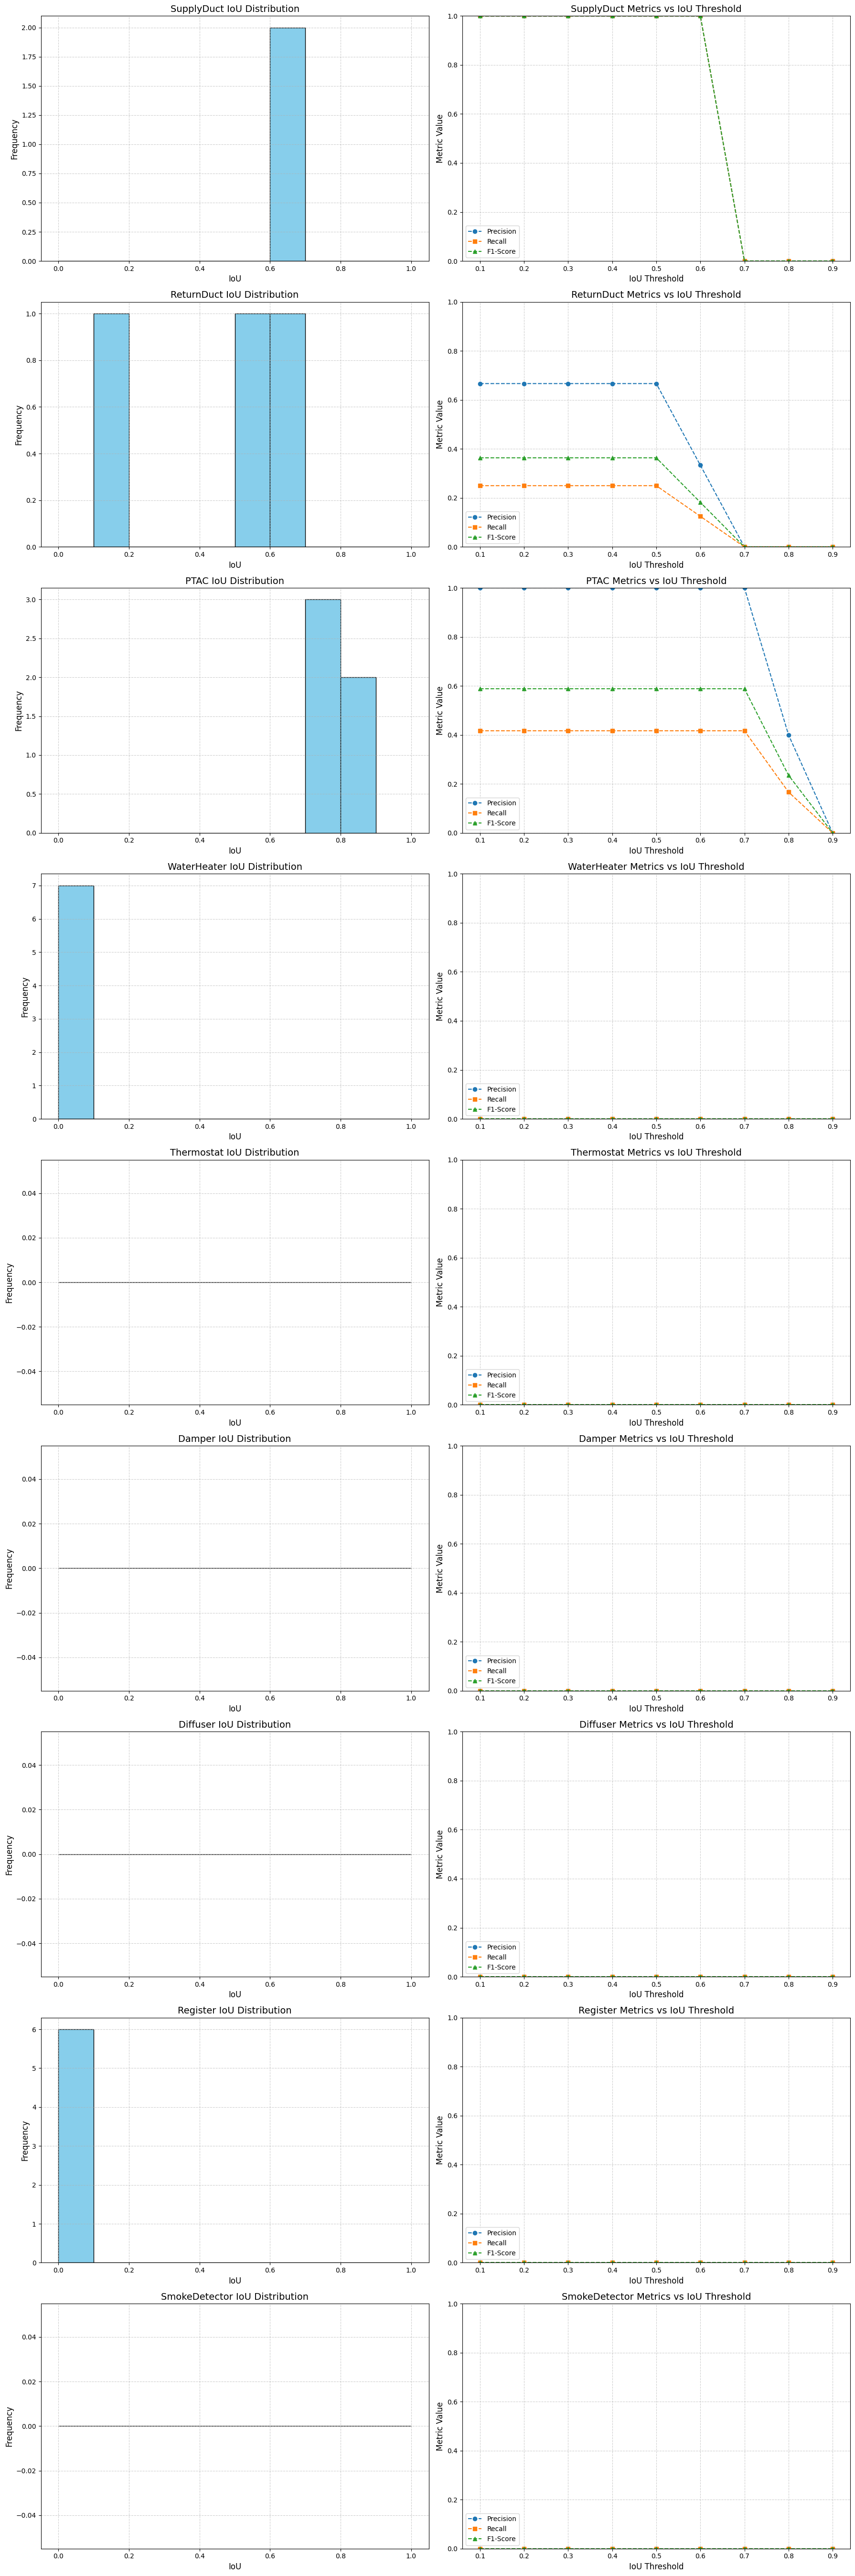

In [ ]:
# Template names and IoU thresholds for analysis
template_names = ["SupplyDuct", "ReturnDuct", "PTAC", "WaterHeater",
    "Thermostat", "Damper", "Diffuser", "Register", "SmokeDetector"]
iou_thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

# Plot metrics for each template type
plot_template_metrics(predicted_boxes, ground_truth_boxes, template_names, iou_thresholds)


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from scipy.io import loadmat
from collections import defaultdict
from shapely.geometry import box
import pandas as pd
import seaborn as sns

# --------------- FUNCTION DEFINITIONS --------------- #

# Preprocess the input image
def preprocess_image(img):
    if len(img.shape) == 3:  # Convert to grayscale if it's a color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)
    eroded = cv2.erode(closed, kernel, iterations=1)
    dilated = cv2.dilate(eroded, kernel, iterations=1)
    dilated_new = cv2.GaussianBlur(dilated, (3, 3), 0)
    return dilated_new

# Preprocess templates
def preprocess_template(img):
    if len(img.shape) == 3:  # Convert to grayscale if it's a color image
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        gray = img
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, binary_img = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)
    kernel = np.ones((1, 1), np.uint8)
    closed = cv2.morphologyEx(binary_img, cv2.MORPH_CLOSE, kernel, iterations=2)
    eroded = cv2.erode(closed, kernel, iterations=3)
    refined = cv2.dilate(eroded, kernel, iterations=3)
    coords = cv2.findNonZero(refined)  # Find non-zero pixels
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        cropped = refined[y:y+h, x:x+w]
    else:
        cropped = refined
    return cropped

# Generate template rotations
def template_rotations(template_img, rotation_angles=[0, 90, 180, 270]):
    rotated_templates = []
    for angle in rotation_angles:
        (h, w) = template_img.shape[:2]
        diagonal = int(np.sqrt(h**2 + w**2))
        canvas_size = (diagonal, diagonal)
        center = (diagonal // 2, diagonal // 2)
        padded_template = cv2.copyMakeBorder(
            template_img,
            top=(diagonal - h) // 2,
            bottom=(diagonal - h) // 2,
            left=(diagonal - w) // 2,
            right=(diagonal - w) // 2,
            borderType=cv2.BORDER_CONSTANT,
            value=0
        )
        M = cv2.getRotationMatrix2D(center, angle, 1.0)
        rotated_template = cv2.warpAffine(padded_template, M, canvas_size)
        coords = cv2.findNonZero(rotated_template)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            rotated_template = rotated_template[y:y+h, x:x+w]
        rotated_templates.append(rotated_template)
    return rotated_templates

# IoU Calculation Function
def calculate_iou(box1, box2):
    """Calculate IoU between two bounding boxes."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    inter_area = inter_width * inter_height

    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = inter_area / (area_box1 + area_box2 - inter_area + 1e-6)  # Avoid division by zero
    return iou

def non_max_suppression_with_scores(boxes, scores, iou_threshold=0.2):
    """
    Perform Non-Maximum Suppression (NMS) on bounding boxes with scores.

    Args:
        boxes (list or ndarray): List/Array of bounding boxes in (x1, y1, x2, y2) format.
        scores (list or ndarray): Corresponding confidence scores for the bounding boxes.
        iou_threshold (float): IoU threshold to suppress overlapping boxes.

    Returns:
        selected_boxes (ndarray): Array of selected bounding boxes.
        selected_scores (ndarray): Array of corresponding scores for selected boxes.
    """
    if len(boxes) == 0:
        return [], []

    # Convert to numpy arrays
    boxes = np.array(boxes, dtype=np.float32)
    scores = np.array(scores, dtype=np.float32)

    # Sort boxes by scores in descending order
    sorted_indices = np.argsort(scores)[::-1]

    selected_boxes = []
    selected_scores = []

    while len(sorted_indices) > 0:
        # Select the highest-scoring box
        current_index = sorted_indices[0]
        selected_boxes.append(boxes[current_index])
        selected_scores.append(scores[current_index])

        # Compute IoUs with remaining boxes
        current_box = boxes[current_index]
        remaining_boxes = boxes[sorted_indices[1:]]
        ious = np.array([calculate_iou(current_box, box) for box in remaining_boxes])

        # Keep indices of boxes with IoU <= threshold
        sorted_indices = sorted_indices[np.where(ious <= iou_threshold)[0] + 1]

    # Convert to numpy arrays and return
    return np.array(selected_boxes, dtype=np.int32), np.array(selected_scores, dtype=np.float32)

def remove_intersections(boxes, scores=None, iou_threshold=0.5):
    """Remove intersecting bounding boxes using IoU threshold."""
    if scores is None:
        scores = [1] * len(boxes)

    non_intersecting_boxes = []
    non_intersecting_scores = []

    for i, current_box in enumerate(boxes):
        keep = True
        for j, other_box in enumerate(non_intersecting_boxes):
            if calculate_iou(current_box, other_box) > iou_threshold:
                if scores[i] > non_intersecting_scores[j]:
                    # Replace the suppressed box with the current higher-score box
                    non_intersecting_boxes[j] = current_box
                    non_intersecting_scores[j] = scores[i]
                keep = False
                break

        if keep:
            non_intersecting_boxes.append(current_box)
            non_intersecting_scores.append(scores[i])

    return non_intersecting_boxes, non_intersecting_scores

def match_templates(image, templates, scales, threshold=0.75, iou_threshold=0.2, max_matches=1000):
    """
    Match templates to the given image at multiple scales and perform NMS.

    Args:
        image: Input image for template matching.
        templates: List of templates (rotations/scales).
        scales: List of scales to resize templates.
        threshold: Confidence threshold for template matching.
        iou_threshold: IoU threshold for Non-Maximum Suppression.

    Returns:
        filtered_matches: Grouped matches after applying NMS.
    """
    unique_template_matches = defaultdict(list)  # Store matches for each template
    template_scores = defaultdict(list)  # Store scores for each match

    print(f"Starting template matching for image of size {image.shape}...")

    # Loop through each set of template variants
    for template_variants, template_name in zip(templates, template_names):
        print(f"Matching template: {template_name}")
        for idx, rotated_template in enumerate(template_variants):
            print(f"Processing rotation {idx + 1} for {template_name}...")
            for scale in scales:
                try:
                    # Resize the template based on scale
                    scaled_template = cv2.resize(rotated_template, (0, 0), fx=scale, fy=scale)
                    h, w = scaled_template.shape[:2]

                    if h <= 0 or w <= 0:
                        print(f"Skipping invalid template size: {h}x{w}")
                        continue

                    print(f"Matching scaled template: {template_name}, scale: {scale}, size: {h}x{w}")

                    # Perform template matching
                    result = cv2.matchTemplate(image, scaled_template, cv2.TM_CCOEFF_NORMED)
                    y_coords, x_coords = np.where(result >= threshold)

                    # Limit the number of matches processed
                    for x, y in zip(x_coords[:max_matches], y_coords[:max_matches]):
                        bbox = [x, y, x + w, y + h]
                        score = result[y, x]
                        unique_template_matches[template_name].append(bbox)
                        template_scores[template_name].append(score)

                except Exception as e:
                    print(f"Error during template matching for {template_name}, scale {scale}: {e}")

    print(f"Completed initial template matching. Applying NMS...")

    # Flatten matches and scores for NMS
    all_boxes = []
    all_scores = []
    all_template_names = []

    for template_name, boxes in unique_template_matches.items():
        for i, box in enumerate(boxes):
            all_boxes.append(box)
            all_scores.append(template_scores[template_name][i])
            all_template_names.append(template_name)

    # Perform NMS
    try:
        filtered_boxes, filtered_scores = non_max_suppression_with_scores(all_boxes, all_scores, iou_threshold)
    except Exception as e:
        print(f"Error during NMS: {e}")
        return {}

    # Group filtered matches by template type
    filtered_matches = defaultdict(list)
    for template_name, box in zip(all_template_names, filtered_boxes):
        filtered_matches[template_name].append(box)

    print(f"Template matching and NMS completed. Filtered matches count: {len(filtered_matches)}")
    return filtered_matches


# Calculate IoU
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter_width = max(0, x2 - x1)
    inter_height = max(0, y2 - y1)
    inter_area = inter_width * inter_height
    area_box1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area_box2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    iou = inter_area / (area_box1 + area_box2 - inter_area + 1e-6)
    return iou

def load_ground_truth(mat_file_path):
    try:
        mat_data = loadmat(mat_file_path)
        if 'labelsStruct' not in mat_data:
            raise ValueError(f"Missing 'labelsStruct' in {mat_file_path}")
        labels_struct = mat_data['labelsStruct']
        ground_truth_boxes = defaultdict(list)
        for row in labels_struct:
            row_data = row[0]
            for i, key in enumerate(template_names):
                bbox_array = row_data[i] if i < len(row_data) else []
                if bbox_array.size > 0:
                    ground_truth_boxes[key].append(bbox_array)
        return ground_truth_boxes
    except Exception as e:
        print(f"Error loading ground truth from {mat_file_path}: {e}")
        return defaultdict(list)

# Generate metrics
def generate_aggregate_metrics_table(all_gt_boxes, all_pred_boxes, iou_threshold):
    metrics = []
    for page, gt_boxes in all_gt_boxes.items():
        pred_boxes = all_pred_boxes.get(page, {})
        for label, gt in gt_boxes.items():
            pred = pred_boxes.get(label, [])
            true_matches = sum(1 for g in gt for p in pred if calculate_iou(g, p) > iou_threshold)
            false_positives = len(pred) - true_matches
            false_negatives = len(gt) - true_matches
            precision = true_matches / (true_matches + false_positives) if (true_matches + false_positives) > 0 else 0
            recall = true_matches / (true_matches + false_negatives) if (true_matches + false_negatives) > 0 else 0
            f1_score = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
            metrics.append({"Page": page, "Label": label, "Precision": precision, "Recall": recall, "F1-Score": f1_score})
    return pd.DataFrame(metrics)

# Visualize matches
def visualize_matches(image, gt_boxes, pred_boxes, title="Matches"):
    vis_image = image.copy()
    for box in gt_boxes:
        x1, y1, x2, y2 = box
        cv2.rectangle(vis_image, (x1, y1), (x2, y2), (255, 0, 0), 2)
    for box in pred_boxes:
        x1, y1, x2, y2 = box
        cv2.rectangle(vis_image, (x1, y1), (x2, y2), (0, 255, 0), 2)
    plt.imshow(cv2.cvtColor(vis_image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

def visualize_metrics(metrics_df):
    plt.figure(figsize=(12, 8))
    sns.heatmap(metrics_df.pivot("Label", "Page", "F1-Score"), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
    plt.title("F1-Score Heatmap by Label and Page")
    plt.xlabel("Page")
    plt.ylabel("Label")
    plt.show()

# --------------- MAIN PIPELINE --------------- #

# Paths for images and templates
image_paths = [f"/content/drive/MyDrive/*Datasets/processed_data/page_{i}.png" for i in range(48, 54)]
tmp_img = cv2.imread("/content/drive/MyDrive/*Datasets/Parkview Data Images/page_47.png")

# Define crop coordinates for additional templates with variations
supply_duct_crop = tmp_img[930:970, 200:300]
return_duct_crop = tmp_img[965:1005, 200:300]
supply_ductwork_up_crop = tmp_img[1010:1040, 260:290]
supply_ductwork_up_crop_2 = tmp_img[1215:1260, 260:290]
return_ductwork_up_crop = tmp_img[1045:1090, 260:290]
return_ductwork_up_crop_2 = tmp_img[1260:1290, 260:290]
return_ductwork_up_crop_3 = tmp_img[1290:1325, 260:290]
supply_ductwork_down_crop = tmp_img[1095:1135, 260:290]
return_ductwork_down_crop = tmp_img[1140:1175, 260:290]
return_ductwork_down_crop_2 = tmp_img[1330:1375, 260:290]
motorized_damper_crop = tmp_img[1470:1500, 220:240]
smoke_detector_crop = tmp_img[1505:1545, 245:290]
ceiling_mounted_diffuser_crop = tmp_img[1545:1590, 230:290]
ceiling_mounted_register_crop = tmp_img[1590:1630, 230:290]
thermostat_crop = tmp_img[1455:1515, 685:710]

# Convert cropped templates to grayscale
cropped_templates = [
    cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    for crop in [
        supply_duct_crop,
        return_duct_crop,
        supply_ductwork_up_crop,
        supply_ductwork_up_crop_2,
        return_ductwork_up_crop,
        return_ductwork_up_crop_2,
        return_ductwork_up_crop_3,
        supply_ductwork_down_crop,
        return_ductwork_down_crop,
        return_ductwork_down_crop_2,
        motorized_damper_crop,
        smoke_detector_crop,
        ceiling_mounted_diffuser_crop,
        ceiling_mounted_register_crop,
        thermostat_crop
    ]
]

# Define additional template paths
template_paths = [
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_1.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_2.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_3.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_legend_4.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/ptac_horizontal.png',
    '/content/drive/MyDrive/*Datasets/Legends and Symbols/Mechanical Legends/Hot Water Heater.png'
]

# Define names for all templates, including variations
template_names = [
    'SupplyDuct',
    'ReturnDuct',
    'SupplyDuct',
    'SupplyDuct',
    'ReturnDuct',
    'ReturnDuct',
    'ReturnDuct',
    'SupplyDuct',
    'ReturnDuct',
    'ReturnDuct',
    'Damper',
    'SmokeDetector',
    'Diffuser',
    'Register',
    'PTAC',
    'PTAC',
    'PTAC',
    'PTAC',
    'PTAC',
    'WaterHeater',
    'Thermostat'
]

# Load additional templates with error handling
additional_templates = []
for path in template_paths:
    template = cv2.imread(path, 0)
    if template is not None:
        additional_templates.append(template)
    else:
        print(f"Warning: Unable to load template from {path}. Skipping...")

# Combine all templates
original_templates = cropped_templates + additional_templates
print("Loaded templates:", len(original_templates))

processed_templates = [preprocess_template(template) for template in original_templates]
print("Processed templates:", len(processed_templates))

# Process images with error handling
processed_images = {}
for i, path in enumerate(image_paths, start=48):
    image = cv2.imread(path)
    if image is not None:
        processed_images[i] = preprocess_image(image)
    else:
        print(f"Warning: Unable to load image from {path}. Skipping...")
print("Processed images:", len(processed_images))

print("Starting template matching...")
# Template matching
all_filtered_matches = {}
for page, image in processed_images.items():
    matches, scores = match_templates(image, processed_templates, scales=[1.0, 0.9])
    all_filtered_matches[page] = matches
print("Template matching completed.")

# Load ground truth
ground_truth_paths = [f"/content/drive/MyDrive/*Datasets/ground_truth_data/page_{i}_labels.mat" for i in range(48, 54)]
all_gt_boxes = {i: load_ground_truth(path) for i, path in enumerate(ground_truth_paths, start=48)}
print("Loaded ground truth boxes:", len(all_gt_boxes))

# Generate metrics
metrics_df = generate_aggregate_metrics_table(all_gt_boxes, all_filtered_matches, iou_threshold=0.5)

# Call visualization
visualize_metrics(metrics_df)

Loaded templates: 21
Processed templates: 21
Processed images: 6
Starting template matching...
Starting template matching for image of size (1012, 1898)...
Matching template: SupplyDuct
Processing rotation 1 for SupplyDuct...
Matching scaled template: SupplyDuct, scale: 1.0, size: 38x1
Matching scaled template: SupplyDuct, scale: 0.9, size: 34x1
Processing rotation 2 for SupplyDuct...
Matching scaled template: SupplyDuct, scale: 1.0, size: 38x1
Matching scaled template: SupplyDuct, scale: 0.9, size: 34x1
Processing rotation 3 for SupplyDuct...
Matching scaled template: SupplyDuct, scale: 1.0, size: 38x1
Matching scaled template: SupplyDuct, scale: 0.9, size: 34x1
Processing rotation 4 for SupplyDuct...
Matching scaled template: SupplyDuct, scale: 1.0, size: 38x1
Matching scaled template: SupplyDuct, scale: 0.9, size: 34x1
Processing rotation 5 for SupplyDuct...
Matching scaled template: SupplyDuct, scale: 1.0, size: 38x1
Matching scaled template: SupplyDuct, scale: 0.9, size: 34x1
Proc

KeyboardInterrupt: 